# Fitting Rotation Curves

## Import packages

In [1]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import scipy.integrate as spint
from scipy.optimize import curve_fit
import csv
from warnings import catch_warnings, simplefilter
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import odr
import matplotlib.cm as cm

⏱ 1.8839s


In [2]:
datadir = "../data/"
outdir = "../outputs/"

sparc = pd.read_csv(datadir+'SPARC_Lelli2016c.mrt.csv')
directory2 = datadir+"SPARC_rotcurves_mod/"
gab_names = np.array(sparc['Name'][np.where(np.array(sparc['Vflat'].tolist()) != 0)[0]].tolist())
gab_names_finc = np.array(sparc['Name'].values[np.where((np.array(sparc['Inc'].values) >= 40) & (np.array(sparc['Inc'].values) <= 79))[0]])

⏱ 0.0136s


In [3]:
len(gab_names_finc), len(gab_names)

(119, 135)

⏱ 0.0015s


In [4]:
gab_names_finc

array(['CamB', 'D512-2', 'D564-8', 'D631-7', 'DDO064', 'DDO154', 'DDO161',
       'DDO168', 'DDO170', 'ESO079-G014', 'ESO116-G012', 'F563-V1',
       'F565-V2', 'F568-3', 'F568-V1', 'F574-1', 'F583-1', 'F583-4',
       'IC2574', 'KK98-251', 'NGC0024', 'NGC0055', 'NGC0247', 'NGC0289',
       'NGC0300', 'NGC1003', 'NGC1090', 'NGC2366', 'NGC2403', 'NGC2841',
       'NGC2903', 'NGC2915', 'NGC2955', 'NGC2976', 'NGC2998', 'NGC3109',
       'NGC3198', 'NGC3521', 'NGC3726', 'NGC3741', 'NGC3769', 'NGC3877',
       'NGC3893', 'NGC3917', 'NGC3949', 'NGC3953', 'NGC3972', 'NGC3992',
       'NGC4051', 'NGC4068', 'NGC4088', 'NGC4100', 'NGC4138', 'NGC4389',
       'NGC4559', 'NGC5005', 'NGC5033', 'NGC5055', 'NGC5371', 'NGC5585',
       'NGC5985', 'NGC6015', 'NGC6195', 'NGC6503', 'NGC6674', 'NGC6789',
       'NGC7331', 'NGC7793', 'PGC51017', 'UGC00128', 'UGC00191',
       'UGC00731', 'UGC00891', 'UGC02259', 'UGC02455', 'UGC02885',
       'UGC02916', 'UGC02953', 'UGC03205', 'UGC03546', 'UGC03580',
     

⏱ 0.0009s


In [5]:
# pd.set_option("display.max_rows", 200)
# pd.set_option("display.max_columns", 50)

⏱ 0.0001s


In [6]:
def tanh(x, vf, rv):
    return vf*np.tanh(x/rv)

def boissier(r, wc, rv):
    return wc*(1-np.exp(-r/rv))

def _clean_rc(df):
    """Return sorted, cleaned (r, v, ev) numpy arrays."""
    r = pd.to_numeric(df['Rad[kpc]'], errors='coerce').to_numpy()
    v = pd.to_numeric(df['Vobs[km/s]'], errors='coerce').to_numpy()
    ev = pd.to_numeric(df['errV[km/s]'], errors='coerce').to_numpy()

    # finite, non-negative radii; finite velocities and errors
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(ev) & (r >= 0)
    r, v, ev = r[m], v[m], ev[m]
    if r.size:
        order = np.argsort(r)
        r, v, ev = r[order], v[order], ev[order]
    # avoid zero/near-zero uncertainties
    ev = np.where(ev <= 0, np.nan, ev)
    # if all errors invalid, fall back to unweighted later
    return r, v, ev

def _initial_guesses(r, v):
    """Data-driven initial guesses; fall back to your old [150, 1] if needed."""
    if len(r) == 0 or len(v) == 0:
        return 150.0, 1.0
    vf0 = float(np.nanpercentile(v, 90)) if np.isfinite(np.nanpercentile(v, 90)) else 150.0
    R  = float(np.nanmax(r)) if np.isfinite(np.nanmax(r)) and np.nanmax(r) > 0 else 1.0
    rv0 = max(0.2, 0.4 * R)
    return vf0, rv0

def _fit_model(model_fn, r, v, ev, p0, bounds):
    """Try weighted fit first; on failure retry unweighted; returns (p, perr) or (nan)."""
    # try weighted fit
    use_weight = np.isfinite(ev).sum() >= max(3, len(ev)//3)
    try_p0 = p0
    for attempt in range(3):
        try:
            with catch_warnings():
                simplefilter("ignore")  # suppress OptimizeWarning etc.
                if use_weight:
                    popt, pcov = curve_fit(model_fn, r, v, sigma=ev, p0=try_p0,
                                           bounds=bounds, absolute_sigma=True, maxfev=200000)
                else:
                    popt, pcov = curve_fit(model_fn, r, v, p0=try_p0,
                                           bounds=bounds, maxfev=200000)
            perr = np.sqrt(np.diag(pcov))
            # sanity: if covariance exploded, mark as nan so we can retry
            if not np.all(np.isfinite(perr)):
                raise RuntimeError("non-finite covariance")
            return popt, perr
        except Exception:
            # second attempt: unweighted if weighted failed, or new p0
            use_weight = False
            # refresh p0 from current data (guard against stuck start)
            try_p0 = _initial_guesses(r, v)
    # failed all attempts
    return np.array([np.nan, np.nan]), np.array([np.nan, np.nan])

⏱ 0.0017s


## Fit

In [7]:
param_list_SPARC_tanh = []
param_list_SPARC_boissier = []
i=0

show_plots = False
for filename in os.listdir(directory2):
    if not filename.endswith(".dat"):
        continue
    filepath = os.path.join(directory2, filename)
    galaxy = os.path.splitext(filename)[0].split('_')[0]

    if galaxy not in gab_names_finc:
        # keep the exact logging style you had
        print(galaxy + " not in the original SPARC dataset\n")
        continue

    #print(galaxy + " in the original SPARC dataset\n")
    df_SPARC = pd.read_table(filepath, sep="\t", usecols=["Rad[kpc]", "Vobs[km/s]", "errV[km/s]"])
    r, v, v_e = _clean_rc(df_SPARC)

    # require enough data to constrain two-parameter models
    if len(r) < 5 or len(v) < 5:
        param_list_SPARC_tanh.append((galaxy, np.nan, np.nan, np.nan, np.nan))
        param_list_SPARC_boissier.append((galaxy, np.nan, np.nan, np.nan, np.nan))
        continue

    # initial guesses and bounds (strictly positive vf, rv)
    p0 = _initial_guesses(r, v)
    bounds = ([1.0, 1e-3], [1000.0, 100.0])

    # tanh fit
    tpopt, tperr = _fit_model(tanh, r, v, v_e, p0=p0, bounds=bounds)
    tvf, trv = tpopt
    tvf_e, trv_e = tperr if np.all(np.isfinite(tperr)) else (np.nan, np.nan)
    param_list_SPARC_tanh.append((galaxy, tvf, tvf_e, trv, trv_e))

    # boissier fit
    bpopt, bperr = _fit_model(boissier, r, v, v_e, p0=p0, bounds=bounds)
    bvf, brv = bpopt
    bvf_e, brv_e = bperr if np.all(np.isfinite(bperr)) else (np.nan, np.nan)
    param_list_SPARC_boissier.append((galaxy, bvf, bvf_e, brv, brv_e))
    
    if show_plots:
        r_the = np.linspace(0, r[-1], 1000)
        
        fig = figure(figsize=(6,6), dpi=150, facecolor='w')
        frame = fig.add_subplot(1,1,1)
        frame.plot(r_the, tanh(r_the, tvf, trv), label=r"Tanh Fit: $V_{flat}=$" + f"{tvf:.1f}"+ r"$\pm$" + f"{tvf_e:.1f} km/s" + r", $R_v=$" + f"{trv:.2f}"+ r"$\pm$" + f"{trv_e:.1f} kpc", color="blue", lw=3)
        frame.plot(r_the, boissier(r_the, bvf, brv), label=r"Fit: $V_{flat}=$" + f"{bvf:.1f}"+ r"$\pm$" + f"{bvf_e:.1f} km/s" + r", $R_v=$" + f"{brv:.2f}"+ r"$\pm$" + f"{brv_e:.1f} kpc", color="red", lw=3)
        frame.scatter(r, v, label=r"Observations", color="black")
        frame.errorbar(r, v, yerr=v_e, fmt = ' ', ecolor = 'grey', capsize = 3, zorder=0)
        frame.set_title(galaxy + " rotation curve", fontsize = 18)
        frame.set_xlabel("Radius (kpc)", fontsize = 15)
        frame.set_ylabel(r"$v_{rot}$ (km s$^{-1}$)", fontsize = 15)
        frame.legend()
        frame.grid()
        frame.show()
        fig.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/'+galaxy+'_fit.png')
    
    i+=1
print(i)

UGC02023 not in the original SPARC dataset

NGC4157 not in the original SPARC dataset

NGC4183 not in the original SPARC dataset

UGC07125 not in the original SPARC dataset

NGC4013 not in the original SPARC dataset

UGC05253 not in the original SPARC dataset

UGC12506 not in the original SPARC dataset

UGC06614 not in the original SPARC dataset

UGC12732 not in the original SPARC dataset

IC4202 not in the original SPARC dataset

UGC06667 not in the original SPARC dataset

UGC00634 not in the original SPARC dataset

UGC02487 not in the original SPARC dataset

UGC05999 not in the original SPARC dataset

F568-1 not in the original SPARC dataset

F571-V1 not in the original SPARC dataset

NGC0801 not in the original SPARC dataset

NGC6946 not in the original SPARC dataset

F563-V2 not in the original SPARC dataset

F567-2 not in the original SPARC dataset

NGC5907 not in the original SPARC dataset

NGC0891 not in the original SPARC dataset

NGC0100 not in the original SPARC dataset

NGC4

In [8]:
with open('../data/SPARC_tanh_vfs_3', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'vrot_t[km/s]', 'vrot_err_t[km/s]', 'Rv_t[kpc]', 'Rv_err_t[kpc]'])
    writer.writerows(param_list_SPARC_tanh)

with open('../data/SPARC_boissier_vfs_3', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'vrot_b[km/s]', 'vrot_err_b[km/s]', 'Rv_b[kpc]', 'Rv_err_b[kpc]'])
    writer.writerows(param_list_SPARC_boissier)

⏱ 0.0015s


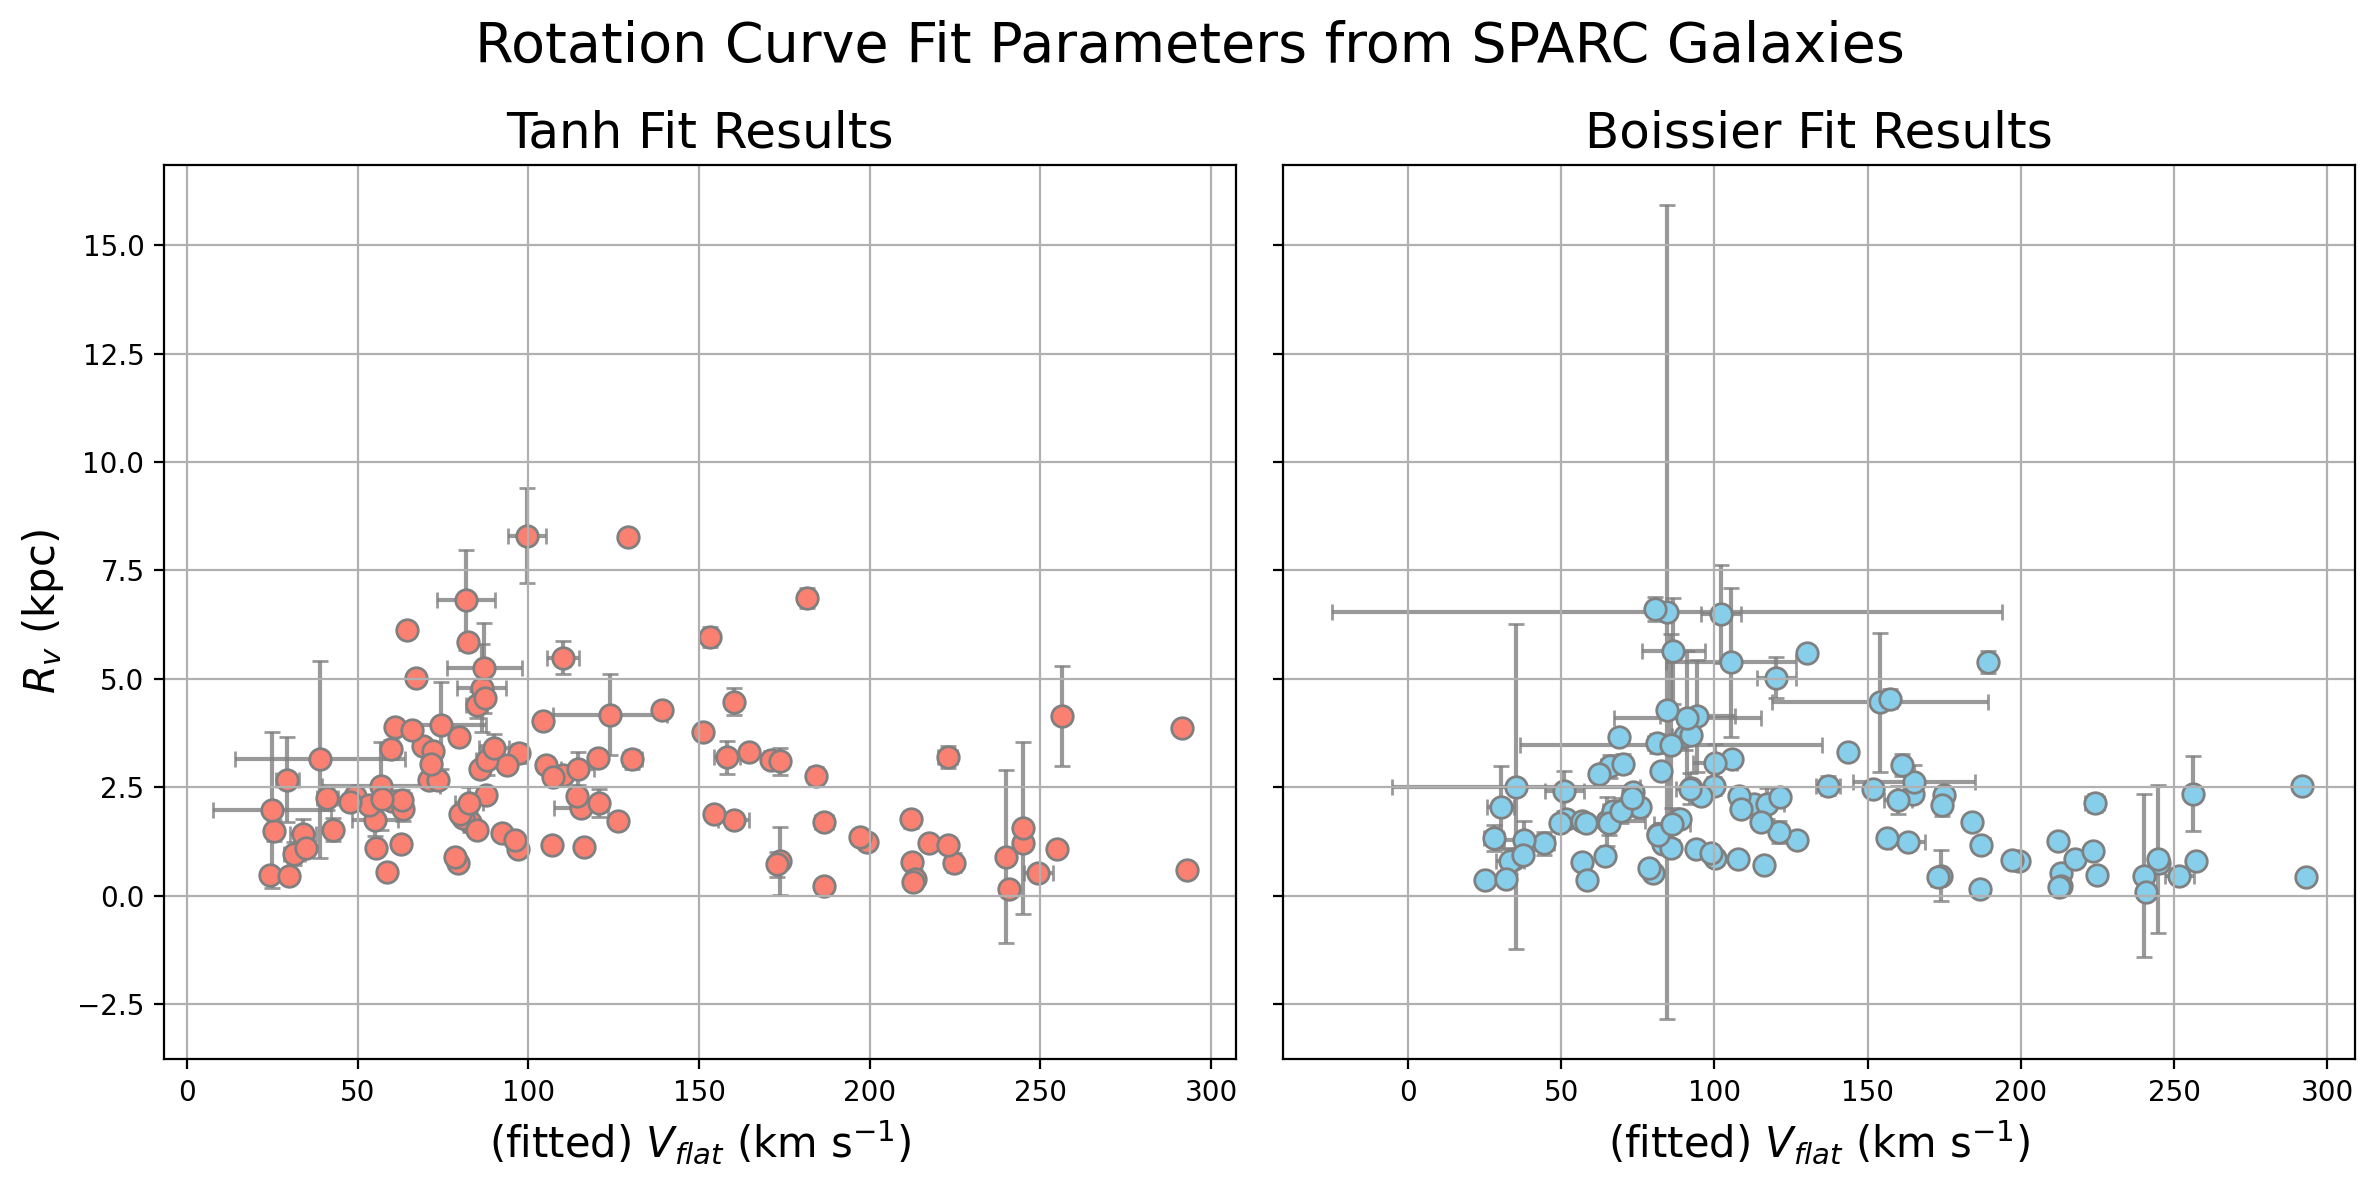

⏱ 0.8831s


In [9]:
# Make plots of Rv vs v_rot for all galaxies from both fit types -- IMPORTANT: v_flat here is the fitted v_rot, not SPARC published v_flat

# index results by galaxy name
tanh_map = {p[0]: p for p in param_list_SPARC_tanh}
bois_map = {p[0]: p for p in param_list_SPARC_boissier}
sparc_idx = (sparc.drop_duplicates('Name').set_index('Name'))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map: 
        continue
    _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vrot_t) and np.isfinite(rvt_err) and np.isfinite(vrot_t_err) and rvt>0 and vrot_t>0 and rvt_err>0 and vrot_t_err>0:
        ax.scatter(vrot_t, rvt, s=60, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vrot_t, rvt, xerr=vrot_t_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"(fitted) $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Tanh Fit Results", fontsize=18)
ax.grid()

ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map: 
        continue
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vrot_b) and np.isfinite(rvb_err) and np.isfinite(vrot_b_err) and rvb>0 and vrot_b>0 and rvb_err>0 and vrot_b_err>0:
        ax.scatter(vrot_b, rvb, s=60, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vrot_b, rvb, xerr=vrot_b_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_xlabel(r"(fitted) $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit Results", fontsize=18)
ax.grid()
plt.suptitle("Rotation Curve Fit Parameters from SPARC Galaxies", fontsize=20)
plt.tight_layout()
#plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat.png')
plt.show()

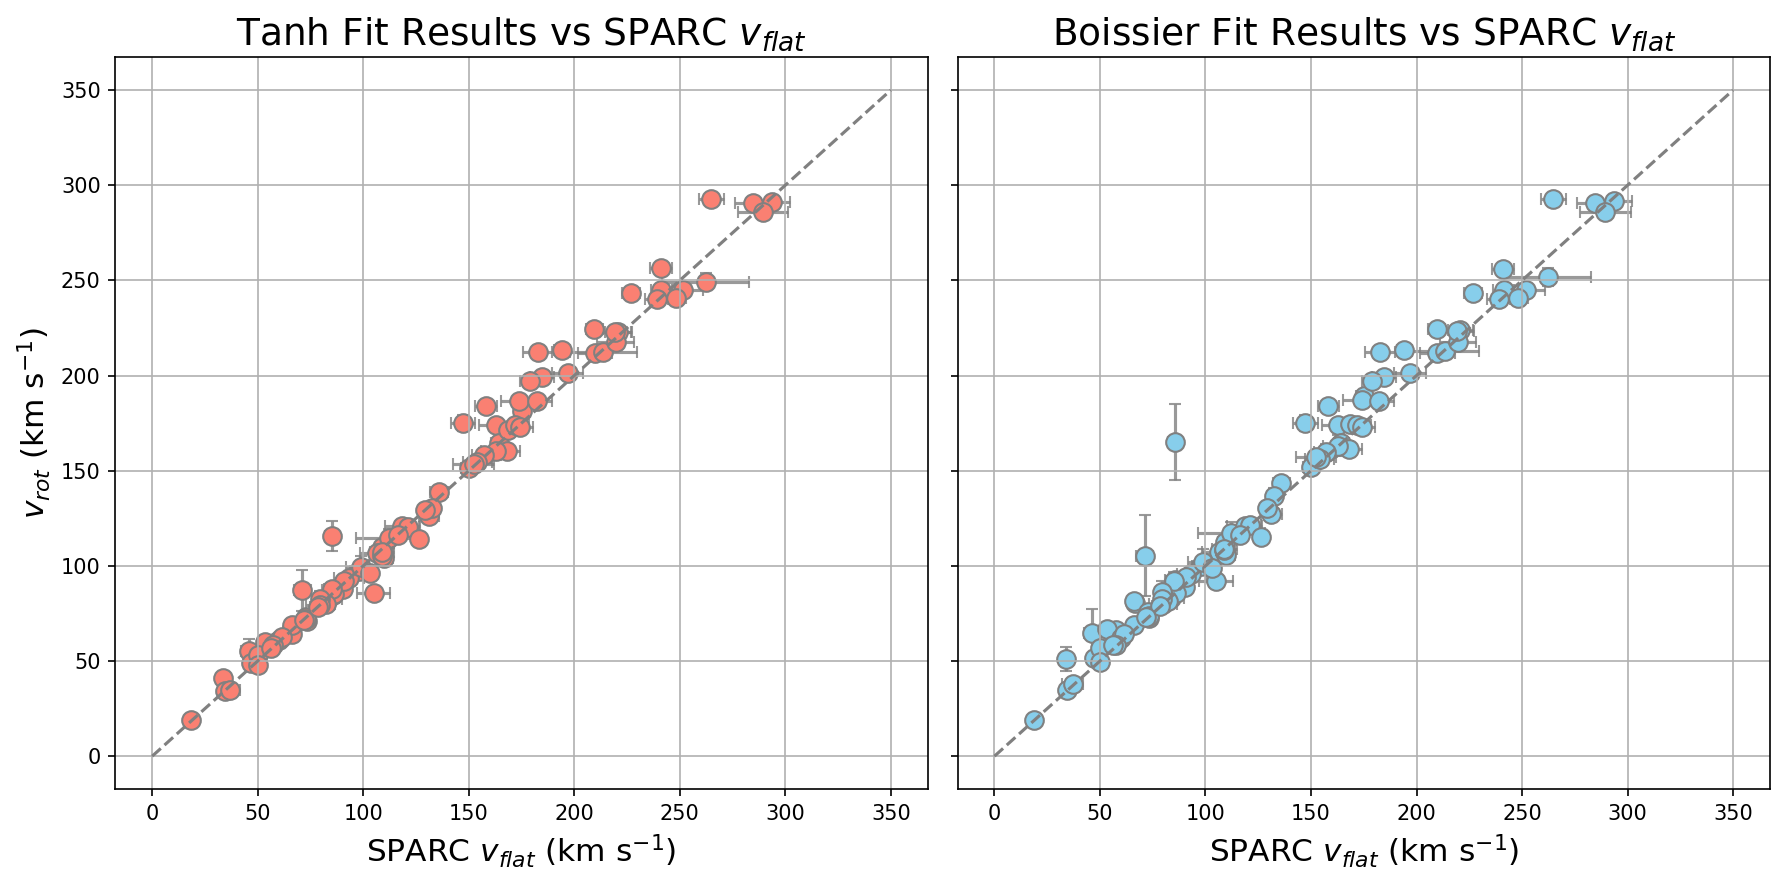

⏱ 0.7210s


In [10]:
# Make plots of v_rot from both fits vs SPARC v_flat sorted so they lie on y=x line

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True, facecolor='w')
ax = axes[0]
for i, galaxy in enumerate(gab_names_finc):
    if galaxy not in tanh_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_t, vrot_t_err, _, _ = tanh_map[galaxy]
    if np.isfinite(vflat) and np.isfinite(vrot_t) and np.isfinite(vflat_err) and np.isfinite(vrot_t_err) and vflat>0 and vrot_t>0 and vflat_err>0 and vrot_t_err>0:
        ax.scatter(vflat, vrot_t, s=80, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, vrot_t, xerr=vflat_err, yerr=vrot_t_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.plot([0, 350], [0, 350], ls='--', c='grey')
ax.set_ylabel(r'$v_{rot}$ (km s$^{-1}$)', fontsize=15)
ax.set_xlabel(r'SPARC $v_{flat}$ (km s$^{-1}$)', fontsize=15)
ax.set_title('Tanh Fit Results vs SPARC $v_{flat}$', fontsize=18)
ax.grid()
ax = axes[1]
for i, galaxy in enumerate(gab_names_finc):
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, _, _ = bois_map[galaxy]
    if np.isfinite(vflat) and np.isfinite(vrot_b) and np.isfinite(vflat_err) and np.isfinite(vrot_b_err) and vflat>0 and vrot_b>0 and vflat_err>0 and vrot_b_err>0:
        ax.scatter(vflat, vrot_b, s=80, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, vrot_b, xerr=vflat_err, yerr=vrot_b_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.plot([0, 350], [0, 350], ls='--', c='grey')
ax.set_xlabel(r'SPARC $v_{flat}$ (km s$^{-1}$)', fontsize=15)
ax.set_title('Boissier Fit Results vs SPARC $v_{flat}$', fontsize=18)
ax.grid()
plt.tight_layout()
plt.show()


In [11]:
names = [n for n in gab_names_finc if n in sparc_idx.index and n in tanh_map and n in bois_map]
bad_vflat = [n for n in names if not (np.isfinite(sparc_idx.at[n,'Vflat']) and sparc_idx.at[n,'Vflat']>0)]
names = [n for n in names if n not in bad_vflat]
rows = []

for n in names:
    _, vt, vt_e, Rt, Rt_e = tanh_map[n]
    _, vb, vb_e, Rb, Rb_e = bois_map.get(n, (np.nan,np.nan,np.nan,np.nan,np.nan))
    vf, evf = float(sparc_idx.at[n,'Vflat']), float(sparc_idx.at[n,'e_Vflat'])
    rows.append((n, vf, evf, vt, vt_e, Rt, Rt_e, vb, vb_e, Rb, Rb_e))

tab = pd.DataFrame(rows, columns=[
    'Name','Vflat','e_Vflat','vrot_t','e_vrot_t','Rv_t','e_Rv_t','vrot_b','e_vrot_b','Rv_b','e_Rv_b'
])

# residuals vs SPARC
tab['Delta_t'] = np.abs(tab['vrot_t'] - tab['Vflat'])
tab['Delta_b'] = np.abs(tab['vrot_b'] - tab['Vflat'])

⏱ 0.0051s


In [12]:
print("Tanh worst |v_rot - V_flat|:")
print(tab.sort_values('Delta_t', ascending=False).head(10)[['Name','Vflat','vrot_t','Delta_t']])

print("\nBoissier worst |v_rot - V_flat|:")
print(tab.sort_values('Delta_b', ascending=False).head(10)[['Name','Vflat','vrot_b','Delta_b']])

Tanh worst |v_rot - V_flat|:
        Name  Vflat      vrot_t    Delta_t
25   NGC2976   85.4  115.449720  30.049720
61  UGC02916  182.7  212.558959  29.858959
62  UGC02953  264.9  292.946644  28.046644
43   NGC4138  147.3  175.229223  27.929223
42   NGC4100  158.2  184.192993  25.992993
15   NGC0247  104.9   85.825287  19.074713
46   NGC5033  194.2  213.173937  18.973937
47   NGC5055  179.0  197.061874  18.061874
88  UGC09133  226.8  243.458935  16.658935
76  UGC06818   71.2   87.143388  15.943388

Boissier worst |v_rot - V_flat|:
        Name  Vflat      vrot_b    Delta_b
25   NGC2976   85.4  165.045825  79.645825
76  UGC06818   71.2  105.447797  34.247797
61  UGC02916  182.7  212.561953  29.861953
62  UGC02953  264.9  293.005370  28.105370
43   NGC4138  147.3  175.229837  27.929837
42   NGC4100  158.2  184.174649  25.974649
46   NGC5033  194.2  213.173952  18.973952
1     DDO064   46.1   64.868370  18.768370
47   NGC5055  179.0  197.105927  18.105927
12  KK98-251   33.7   50.993640  1

In [13]:
# absolute thresholds
sus_t_abs = tab[(tab['Rv_t'] > 4) & (tab['vrot_t'] > 150)]
sus_b_abs = tab[(tab['Rv_b'] > 4) & (tab['vrot_b'] > 150)]
print("Tanh high Rv & high v_rot:\n", sus_t_abs[['Name', 'Rv_t', 'e_Rv_t','vrot_t', 'e_vrot_t', 'Delta_t']])
print("Boissier high Rv & high v_rot:\n", sus_b_abs[['Name', 'Rv_b', 'e_Rv_b', 'vrot_b', 'e_vrot_b', 'Delta_b']])

# percentile
# qt_R, qt_V = tab['Rv_t'].quantile(0.95), tab['vrot_t'].quantile(0.95)
# qb_R, qb_V = tab['Rv_b'].quantile(0.95), tab['vrot_b'].quantile(0.95)
# sus_t_pct = tab[(tab['Rv_t'] >= qt_R) & (tab['vrot_t'] >= qt_V)]
# sus_b_pct = tab[(tab['Rv_b'] >= qb_R) & (tab['vrot_b'] >= qb_V)]
# print("Tanh top-5% both:", sus_t_pct[['Name','Rv_t','vrot_t']])
# print("Boissier top-5% both:", sus_b_pct[['Name','Rv_b','vrot_b']])

Tanh high Rv & high v_rot:
            Name      Rv_t    e_Rv_t      vrot_t  e_vrot_t    Delta_t
6   ESO079-G014  6.863583  0.239379  181.485547  1.621227   6.485547
30      NGC3726  4.475887  0.315761  160.141553  2.115697   7.858447
39      NGC3992  4.152864  1.153141  256.305147  2.213987  15.305147
87     UGC09037  5.967211  0.228512  153.271899  1.791107   0.971899
Boissier high Rv & high v_rot:
            Name      Rv_b    e_Rv_b      vrot_b  e_vrot_b    Delta_b
6   ESO079-G014  5.387990  0.248535  189.341620  2.419697  14.341620
87     UGC09037  4.544098  0.219209  157.183482  2.157375   4.883482
⏱ 0.0099s


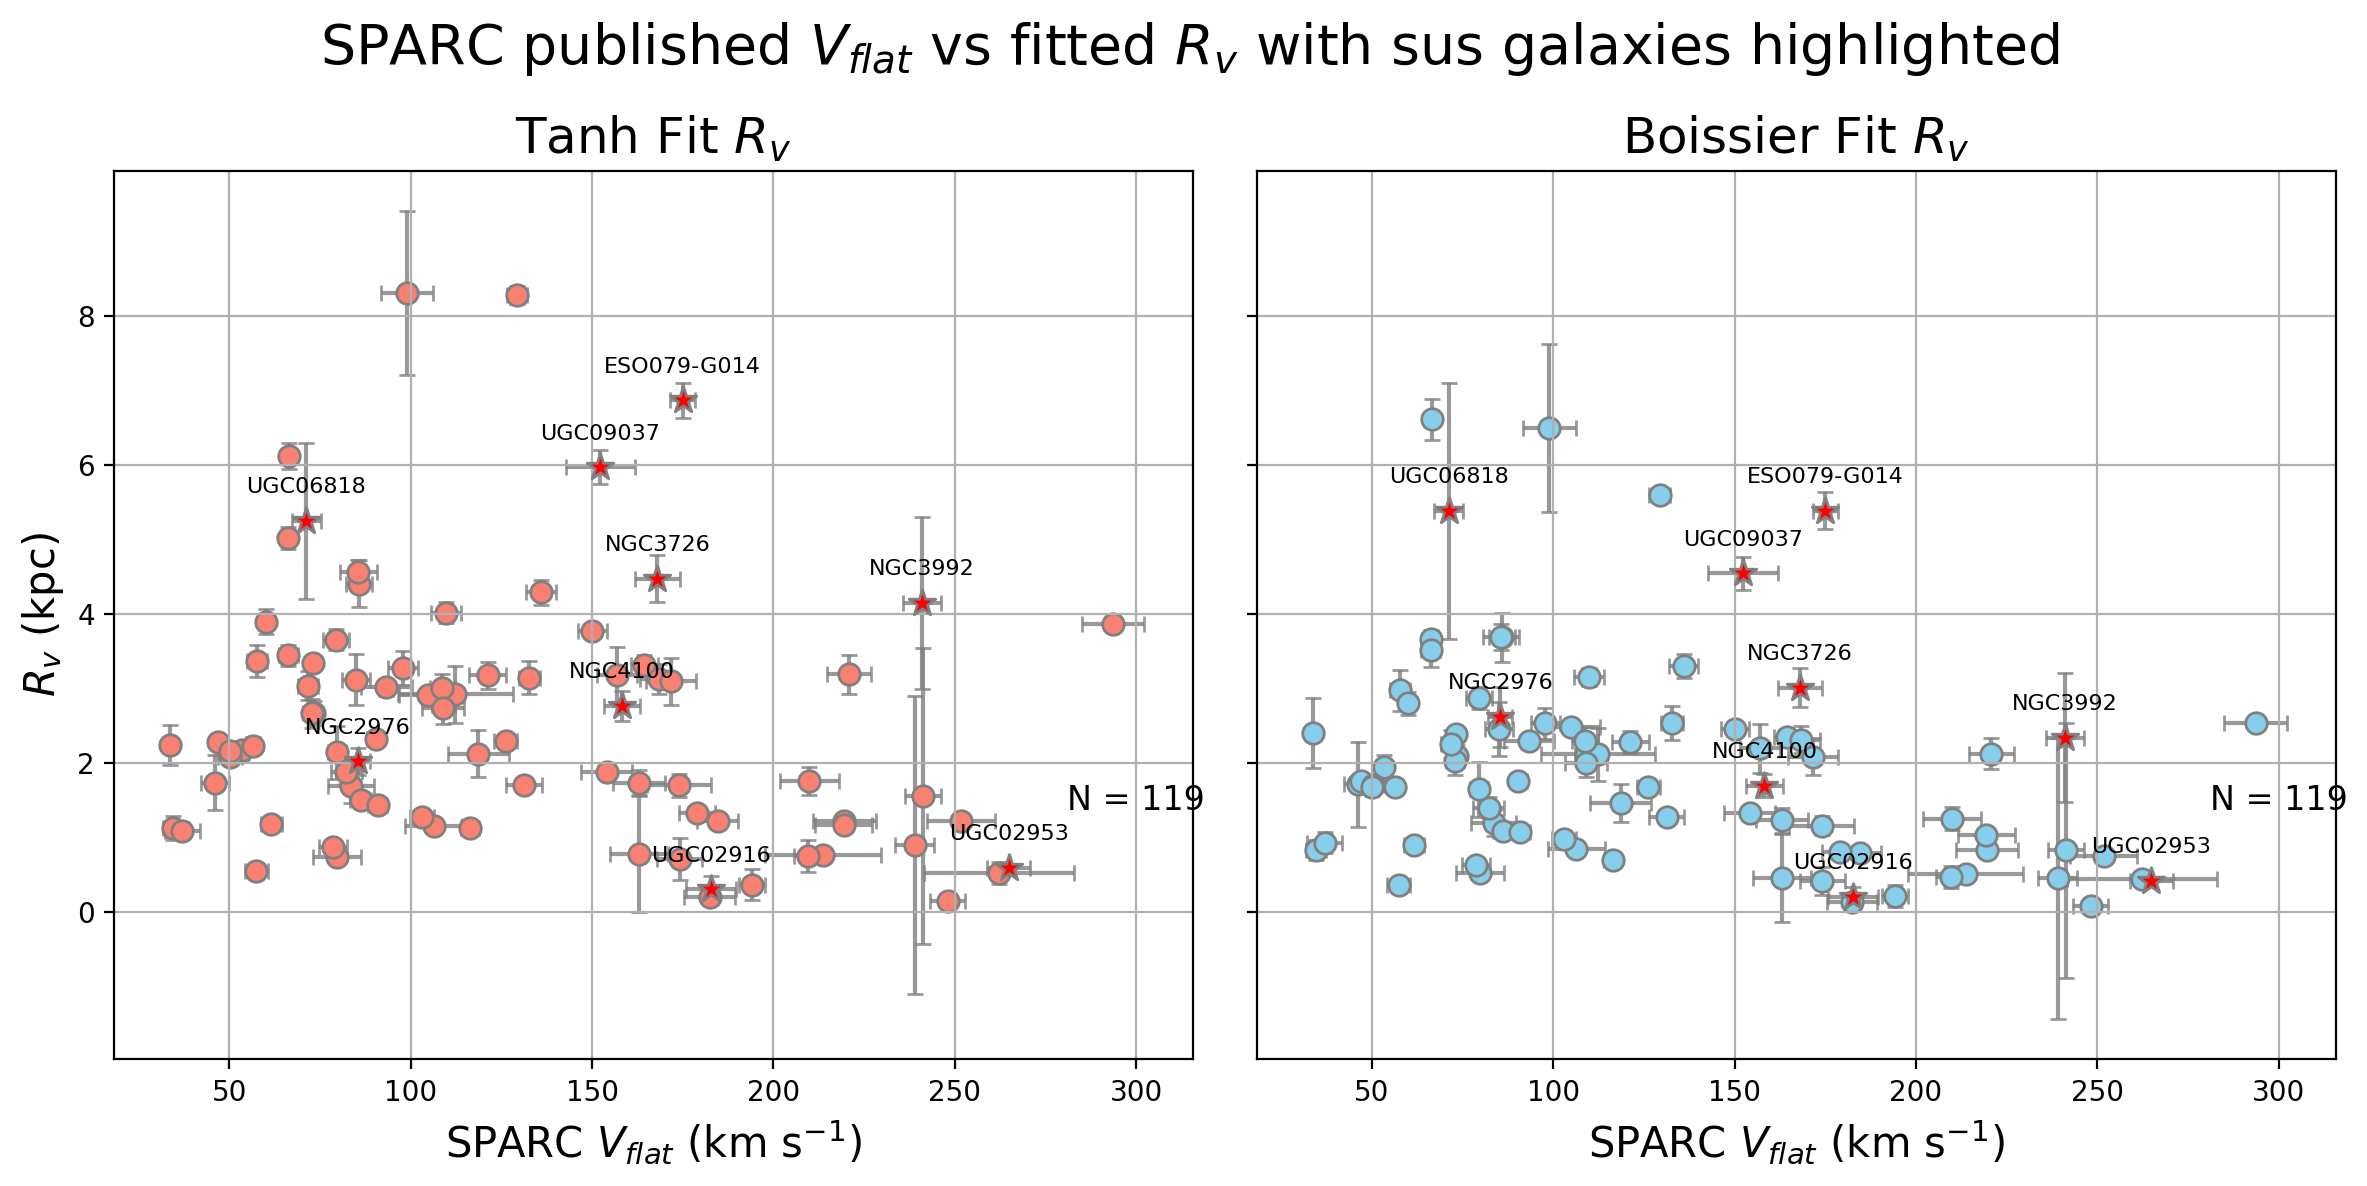

⏱ 0.6789s


In [14]:
# Make v_flat vs R_v plots using the SPARC published v_flat instead. Highlight suspicious galaxies with annotated name next to point
# IMPORTANT: here v_flat is from SPARC, not the fitted v_rot

# index sus galaxies
sus_t = set(sus_t_abs['Name'].tolist())
sus_b = set(sus_b_abs['Name'].tolist())
sus_all = sus_t | sus_b

# Add sus galaxies that have very high Delta_t or Delta_b even if they don't have high Rv and v_rot
sus_t_extra = set(tab[tab['Delta_t'] > 25]['Name'].tolist())
sus_b_extra = set(tab[tab['Delta_b'] > 25]['Name'].tolist())
sus_all_extra = sus_all | sus_t_extra | sus_b_extra

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vflat) and np.isfinite(rvt_err) and np.isfinite(vflat_err) and rvt>0 and vflat>0 and rvt_err>0 and vflat_err>0:
        if galaxy in sus_all_extra:
            ax.scatter(vflat, rvt, s=100, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvt), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvt, s=60, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, rvt, xerr=vflat_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.annotate(f"N = {len(gab_names_finc)}", (300, 1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='k')
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Tanh Fit $R_v$", fontsize=18)
ax.grid()
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vflat) and np.isfinite(rvb_err) and np.isfinite(vflat_err) and rvb>0 and vflat>0 and rvb_err>0 and vflat_err>0:
        if galaxy in sus_all_extra:
            ax.scatter(vflat, rvb, s=100, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvb), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvb, s=60, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, rvb, xerr=vflat_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.annotate(f"N = {len(gab_names_finc)}", (300, 1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='k')
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Boissier Fit $R_v$", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC published $V_{flat}$ vs fitted $R_{v}$ with sus galaxies highlighted", fontsize=20)
plt.tight_layout()
#plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat_using_SPARC_vflat.png')
plt.show()

In [15]:
# sus_all = sus_all if 'sus_all' in globals() else set()

sus_t_fit = set(tab[tab['Delta_t'] > 25]['Name'].tolist())
sus_b_fit = set(tab[tab['Delta_b'] > 25]['Name'].tolist())
# sus_t_error = set(tab[tab['e_Rv_t'] > 1]['Name'].tolist())
# sus_b_error = set(tab[tab['e_Rv_b'] > 1]['Name'].tolist())

sus_high_vflat_high_rv = set()
for g in gab_names_finc:
    if g not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[g, 'Vflat']
    if not (np.isfinite(vflat) and vflat > 200):
        continue

    high_rv = False
    if g in tanh_map:
        _, _, _, rvt, _ = tanh_map[g]
        if np.isfinite(rvt) and rvt > 2:
            high_rv = True
    if not high_rv and g in bois_map:
        _, _, _, rvb, _ = bois_map[g]
        if np.isfinite(rvb) and rvb > 2:
            high_rv = True
    if high_rv:
        sus_high_vflat_high_rv.add(g)

sus_from_maps = set()
for g in gab_names_finc:
    if g in tanh_map:
        _, _, _, rvt, rvt_err = tanh_map[g]
        if np.isfinite(rvt_err) and (rvt_err > 1): sus_from_maps.add(g)
        if np.isfinite(rvt) and (rvt < 0.5): sus_from_maps.add(g)
    if g in bois_map:
        _, _, _, rvb, rvb_err = bois_map[g]
        if np.isfinite(rvb_err) and (rvb_err > 1): sus_from_maps.add(g)
        if np.isfinite(rvb) and (rvb < 0.5): sus_from_maps.add(g)
sus_all_fit = sus_all | sus_t_fit | sus_b_fit | sus_high_vflat_high_rv# | sus_from_maps | sus_t_error | sus_b_error
print("Galaxies excluded from fit:\n", sus_all_fit)

Galaxies excluded from fit:
 {'NGC4138', 'UGC02916', 'UGC06818', 'NGC2976', 'NGC3726', 'NGC5985', 'UGC02953', 'UGC09037', 'NGC3992', 'ESO079-G014', 'NGC4100', 'NGC3953'}
⏱ 0.0036s


Boissier fit parameters with uncertainties (intercept, slope): 2.7481166379567985 -0.010590913923504607 [[ 9.03082316e-04 -6.45093250e-06]
 [-6.45093250e-06  5.51043421e-08]]
75


/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_92301/2127340737.py:92: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(x_fit), np.log10(y_fit), ls='--', c='black', label=rf'ODR fit: $\gamma = {b:.3f}, \delta = {a:.2f}$')
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_92301/2127340737.py:94: RuntimeWarning: invalid value encountered in log10
  ax.fill_between(np.log10(x_fit), np.log10(y_fit)-1.96*sigma, np.log10(y_fit)+1.96*sigma, color='k', alpha=0.08, lw=0)


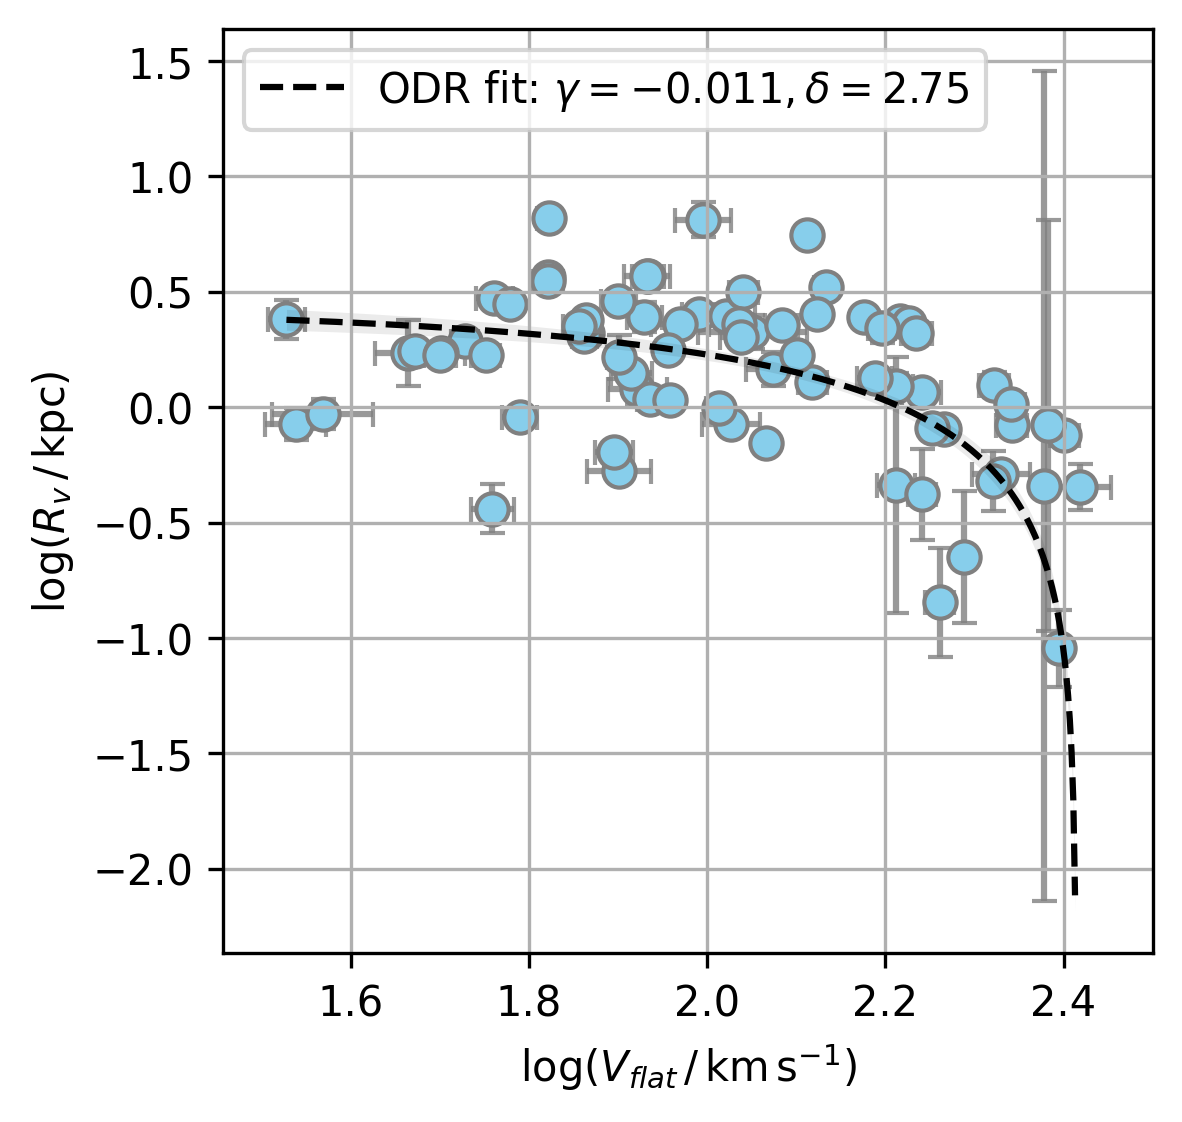

⏱ 0.6225s


In [17]:
# Fit R_v vs v_flat with a line, excluding sus galaxies, plot the fit with data

fig, axes = plt.subplots(1, 1, figsize=(4, 4), dpi=300, sharey=True, facecolor='w')

# TANH
# ax = axes[0]
# for galaxy in gab_names_finc:
#     if galaxy not in tanh_map or galaxy not in sparc_idx.index:
#         continue
#     vflat     = sparc_idx.at[galaxy, 'Vflat']
#     vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
#     _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
#     if np.isfinite(rvt) and np.isfinite(vflat) and np.isfinite(rvt_err) and np.isfinite(vflat_err) and rvt>0 and vflat>0 and rvt_err>0 and vflat_err>0:
#         if galaxy in sus_all_fit:
#             ax.scatter(np.log10(vflat), np.log10(rvt), s=100, c='red', edgecolors='grey', marker='*', zorder=5)
#             ax.annotate(galaxy, (np.log10(vflat), np.log10(rvt)), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
#         else:
#             ax.scatter(np.log10(vflat), np.log10(rvt), s=60, c='salmon', edgecolors='grey')
#         ax.errorbar(np.log10(vflat), np.log10(rvt), xerr=vflat_err/vflat/np.log(10), yerr=rvt_err/rvt/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)

# mask = (~tab['Name'].isin(sus_all_fit) &
#         np.isfinite(tab['Rv_t']) & (tab['Rv_t'] > 0) &
#         np.isfinite(tab['e_Rv_t']) & (tab['e_Rv_t'] > 0) &
#         np.isfinite(tab['Vflat']) & (tab['Vflat'] > 0) &
#         np.isfinite(tab['e_Vflat']) & (tab['e_Vflat'] > 0))

# x  = tab.loc[mask, 'Vflat'].to_numpy()
# sx = tab.loc[mask, 'e_Vflat'].to_numpy()
# y  = tab.loc[mask, 'Rv_t'].to_numpy()
# sy = tab.loc[mask, 'e_Rv_t'].to_numpy()

# lin  = odr.Model(lambda B, x: B[0] + B[1]*x)
# data = odr.RealData(x, y, sx=sx, sy=sy)
# beta0 = np.polyfit(x, y, 1)[::-1]
# out   = odr.ODR(data, lin, beta0=beta0).run()
# a, b  = out.beta
# cov   = out.cov_beta
# print("Tanh fit parameters with uncertainties (intercept, slope):", a, b, cov)

# x_fit = np.linspace(x.min(), x.max(), 200)
# y_fit = a + b*x_fit
# ax.plot(np.log10(x_fit), np.log10(y_fit), ls='--', c='black', label=rf'ODR fit: ({b:.3f}$ \pm {cov[1,1]:.3e}) v_{{\rm flat}} +({a:.2f} \pm {cov[0,0]:.3e})$')
# sigma = np.sqrt(cov[0,0] + x_fit**2*cov[1,1] + 2*x_fit*cov[0,1])
# ax.fill_between(np.log10(x_fit), np.log10(y_fit)-1.96*sigma, np.log10(y_fit)+1.96*sigma, color='k', alpha=0.08, lw=0)
# ax.legend()
# ax.set_ylabel(r"log $R_v$ (log kpc)", fontsize=15)
# ax.set_xlabel(r"SPARC log $V_{flat}$ log (km s$^{-1}$)", fontsize=15)
# ax.set_title(r"Tanh Fit $R_v$", fontsize=18)
# ax.grid()

# BOISSIER
incl_galaxies = []
ax = axes
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vflat) and np.isfinite(rvb_err) and np.isfinite(vflat_err) and rvb>0 and vflat>0 and rvb_err>0 and vflat_err>0:
        if galaxy in sus_all_fit:
            continue
            # ax.scatter(np.log10(vflat), np.log10(rvb), s=100, c='red', edgecolors='grey', marker='*', zorder=5)
            # ax.annotate(galaxy, (np.log10(vflat), np.log10(rvb)), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(np.log10(vflat), np.log10(rvb), s=60, c='skyblue', edgecolors='grey')
            incl_galaxies.append(galaxy)
        ax.errorbar(np.log10(vflat), np.log10(rvb), xerr=vflat_err/vflat/np.log(10), yerr=rvb_err/rvb/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)

mask = (~tab['Name'].isin(sus_all_fit) &
        np.isfinite(tab['Rv_b']) & (tab['Rv_b'] > 0) &
        np.isfinite(tab['e_Rv_b']) & (tab['e_Rv_b'] > 0) &
        np.isfinite(tab['Vflat']) & (tab['Vflat'] > 0) &
        np.isfinite(tab['e_Vflat']) & (tab['e_Vflat'] > 0))

x  = tab.loc[mask, 'Vflat'].to_numpy()
sx = tab.loc[mask, 'e_Vflat'].to_numpy()
y  = tab.loc[mask, 'Rv_b'].to_numpy()
sy = tab.loc[mask, 'e_Rv_b'].to_numpy()

lin  = odr.Model(lambda B, x: B[0] + B[1]*x)
data = odr.RealData(x, y, sx=sx, sy=sy)
beta0 = np.polyfit(x, y, 1)[::-1]
out   = odr.ODR(data, lin, beta0=beta0).run()
a, b  = out.beta
cov   = out.cov_beta
print("Boissier fit parameters with uncertainties (intercept, slope):", a, b, cov)

#add uncertainties to the fit line label
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a + b*x_fit
ax.plot(np.log10(x_fit), np.log10(y_fit), ls='--', c='black', label=rf'ODR fit: $\gamma = {b:.3f}, \delta = {a:.2f}$')
sigma = np.sqrt(cov[0,0] + x_fit**2*cov[1,1] + 2*x_fit*cov[0,1])
ax.fill_between(np.log10(x_fit), np.log10(y_fit)-1.96*sigma, np.log10(y_fit)+1.96*sigma, color='k', alpha=0.08, lw=0)
ax.legend()

#ax.annotate(f"N = {len(incl_galaxies)}", (1.8, -1.5), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='k')
print(len(incl_galaxies))
ax.set_xlabel(r"$\log (V_{flat} \, / \, \mathrm{km\, s^{-1}})$")
ax.set_ylabel(r"$\log (R_v \, / \, \mathrm{kpc})$")
#ax.set_title(r"Boissier Fit $R_v$", fontsize=18)
#ax.set_title(r"SPARC $\log V_{flat}$ vs fitted $\log R_{v}$", fontsize=18)
ax.grid()

#plt.suptitle(r"SPARC published log $V_{flat}$ vs fitted log $R_{v}$ with sus galaxies highlighted and linear fit", fontsize=20)
#plt.tight_layout()
#plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat_with_fit_excl_sus.png')
plt.savefig(outdir+'rotcurves/plots/SPARC_Rv_vs_Vflat_with_fit_excl_sus_boissier.pdf', dpi=300, bbox_inches = "tight")
plt.show()

In [17]:
# print galaxy name of galaxies and v_flat with highest v_flat out of the non-sus ones
non_sus_galaxies = [n for n in names if n not in sus_all_fit]
non_sus_tab = tab[tab['Name'].isin(non_sus_galaxies)]
top5_tanh = non_sus_tab.sort_values('vrot_t', ascending=False).head(5)
top5_boissier = non_sus_tab.sort_values('vrot_b', ascending=False).head(5)

print("Top 5 non-sus galaxies by v_rot from Tanh fit:")
print(top5_tanh[['Name', 'vrot_t', 'e_vrot_t', 'Vflat', 'e_Vflat']])
print("\nTop 5 non-sus galaxies by v_rot from Boissier fit:")
print(top5_boissier[['Name', 'vrot_b', 'e_vrot_b', 'Vflat', 'e_Vflat']])

Top 5 non-sus galaxies by v_rot from Tanh fit:
        Name      vrot_t  e_vrot_t  Vflat  e_Vflat
22   NGC2841  290.490574  0.749994  284.8      8.6
60  UGC02885  285.842056  2.294157  289.5     12.0
45   NGC5005  249.367618  4.282803  262.2     20.7
52   NGC6195  244.774929  1.288961  251.7      9.3
54   NGC6674  244.766187  0.668029  241.3      4.9

Top 5 non-sus galaxies by v_rot from Boissier fit:
        Name      vrot_b  e_vrot_b  Vflat  e_Vflat
22   NGC2841  290.491002  0.749994  284.8      8.6
60  UGC02885  285.842091  2.294157  289.5     12.0
45   NGC5005  251.726178  4.744713  262.2     20.7
52   NGC6195  244.918550  1.319360  251.7      9.3
54   NGC6674  244.765590  0.668044  241.3      4.9
⏱ 0.0053s


In [18]:
# print name and Rv_b Rv_t of galaxies with SPARC v_flat ~ 225 km/s
target_vflat = 225
tolerance = 5  # km/s
close_vflat_galaxies = tab[(tab['Vflat'] >= target_vflat - tolerance) & (tab['Vflat'] <= target_vflat + tolerance)]
print(f"\nGalaxies with SPARC v_flat around {target_vflat} km/s ± {tolerance} km/s:")
print(close_vflat_galaxies[['Name', 'Vflat', 'e_Vflat', 'Rv_t', 'e_Rv_t', 'Rv_b', 'e_Rv_b']])


Galaxies with SPARC v_flat around 225 km/s ± 5 km/s:
        Name  Vflat  e_Vflat      Rv_t    e_Rv_t      Rv_b   e_Rv_b
37   NGC3953  220.8      6.1  3.190698  0.258921  2.130892  0.21328
88  UGC09133  226.8      4.2  0.001001  0.000000  0.001124  0.00000
⏱ 0.0025s


I had to exclude galaxies with too low $R_v$ (fit is bad), too high difference between the fitted and published $v_{\mathrm{flat}}$ values, galaxies with inclination <40 and >79 (especially large inclination gave galaxies too edge on and with possible gas holes; chose 79 because there is a galaxy with Inc=79 that I checked and looks incredibly edge on, so I kinda have to remove that too). Also, remove galaxies with negative values, non zero errors, etc.  Also excluded galaxies with too high $R_v$ error (>1 kpc) which I checked and usually are galaxies which never reached the $v_\mathrm{flat}$ part of the rotation curve.

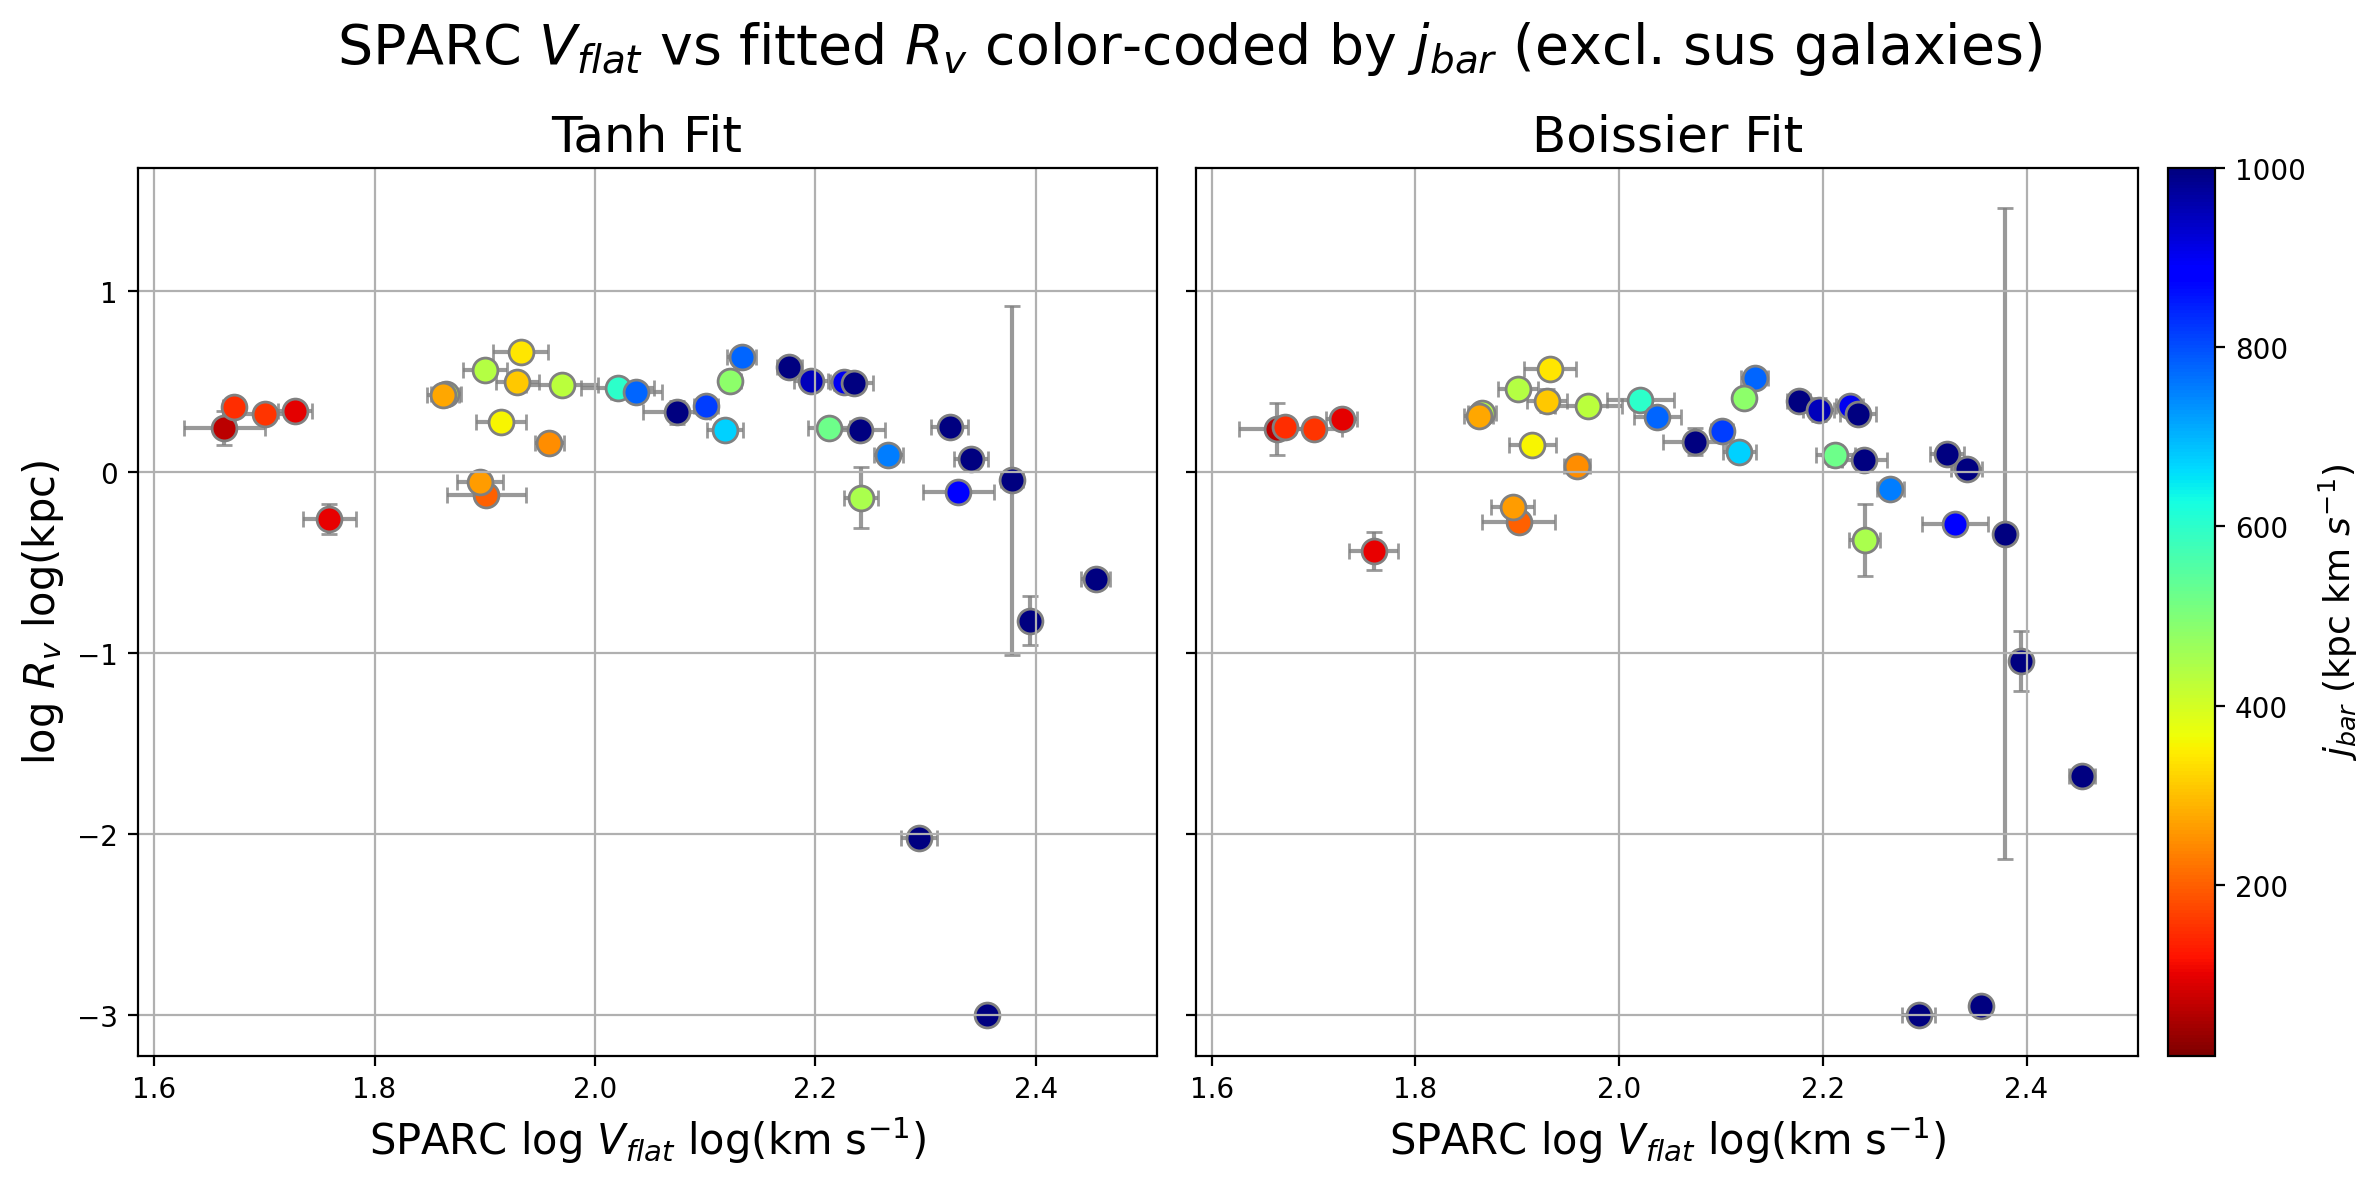

⏱ 0.6122s


In [19]:
# plot again log r_v vs SPARC log v_flat but color-coded by j_bar, excluding sus galaxies

bary = pd.read_csv(datadir+'baryons1.csv')
bary_idx = bary.set_index('Name')
j_bar, j_bar_err, f_gas = bary['j'], bary['e_j'], bary['fgas']

def finite_pos(*vals):
    vals = np.asarray(vals, dtype=float)
    return np.isfinite(vals).all() and (vals > 0).all()

cmap = cm.jet_r

norm = mpl.colors.Normalize(vmin=np.nanmin(j_bar.values), vmax=1000)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')

# TANH
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    if finite_pos(rvt, vflat, jbar):
        color = cmap(norm(jbar))
        ax.scatter(np.log10(vflat), np.log10(rvt), s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(np.log10(vflat), np.log10(rvt), xerr=vflat_err/vflat/np.log(10), yerr=rvt_err/rvt/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_ylabel(r"log $R_v$ log(kpc)", fontsize=15)
ax.set_xlabel(r"SPARC log $V_{flat}$ log(km s$^{-1}$)", fontsize=15)
ax.set_title("Tanh Fit", fontsize=18)
ax.grid()

# BOISSIER
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    if finite_pos(rvb, vflat, jbar):
        color = cmap(norm(jbar))
        ax.scatter(np.log10(vflat), np.log10(rvb), s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(np.log10(vflat), np.log10(rvb), xerr=vflat_err/vflat/np.log(10), yerr=rvb_err/rvb/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
    
ax.set_xlabel(r"SPARC log $V_{flat}$ log(km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC $V_{flat}$ vs fitted $R_{v}$ color-coded by $j_{bar}$ (excl. sus galaxies)", fontsize=20)

divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(r"$j_{bar}$ (kpc km $s^{-1})$", fontsize=13)

plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/jbar_vs_Rv_excl_sus.png')
plt.show()

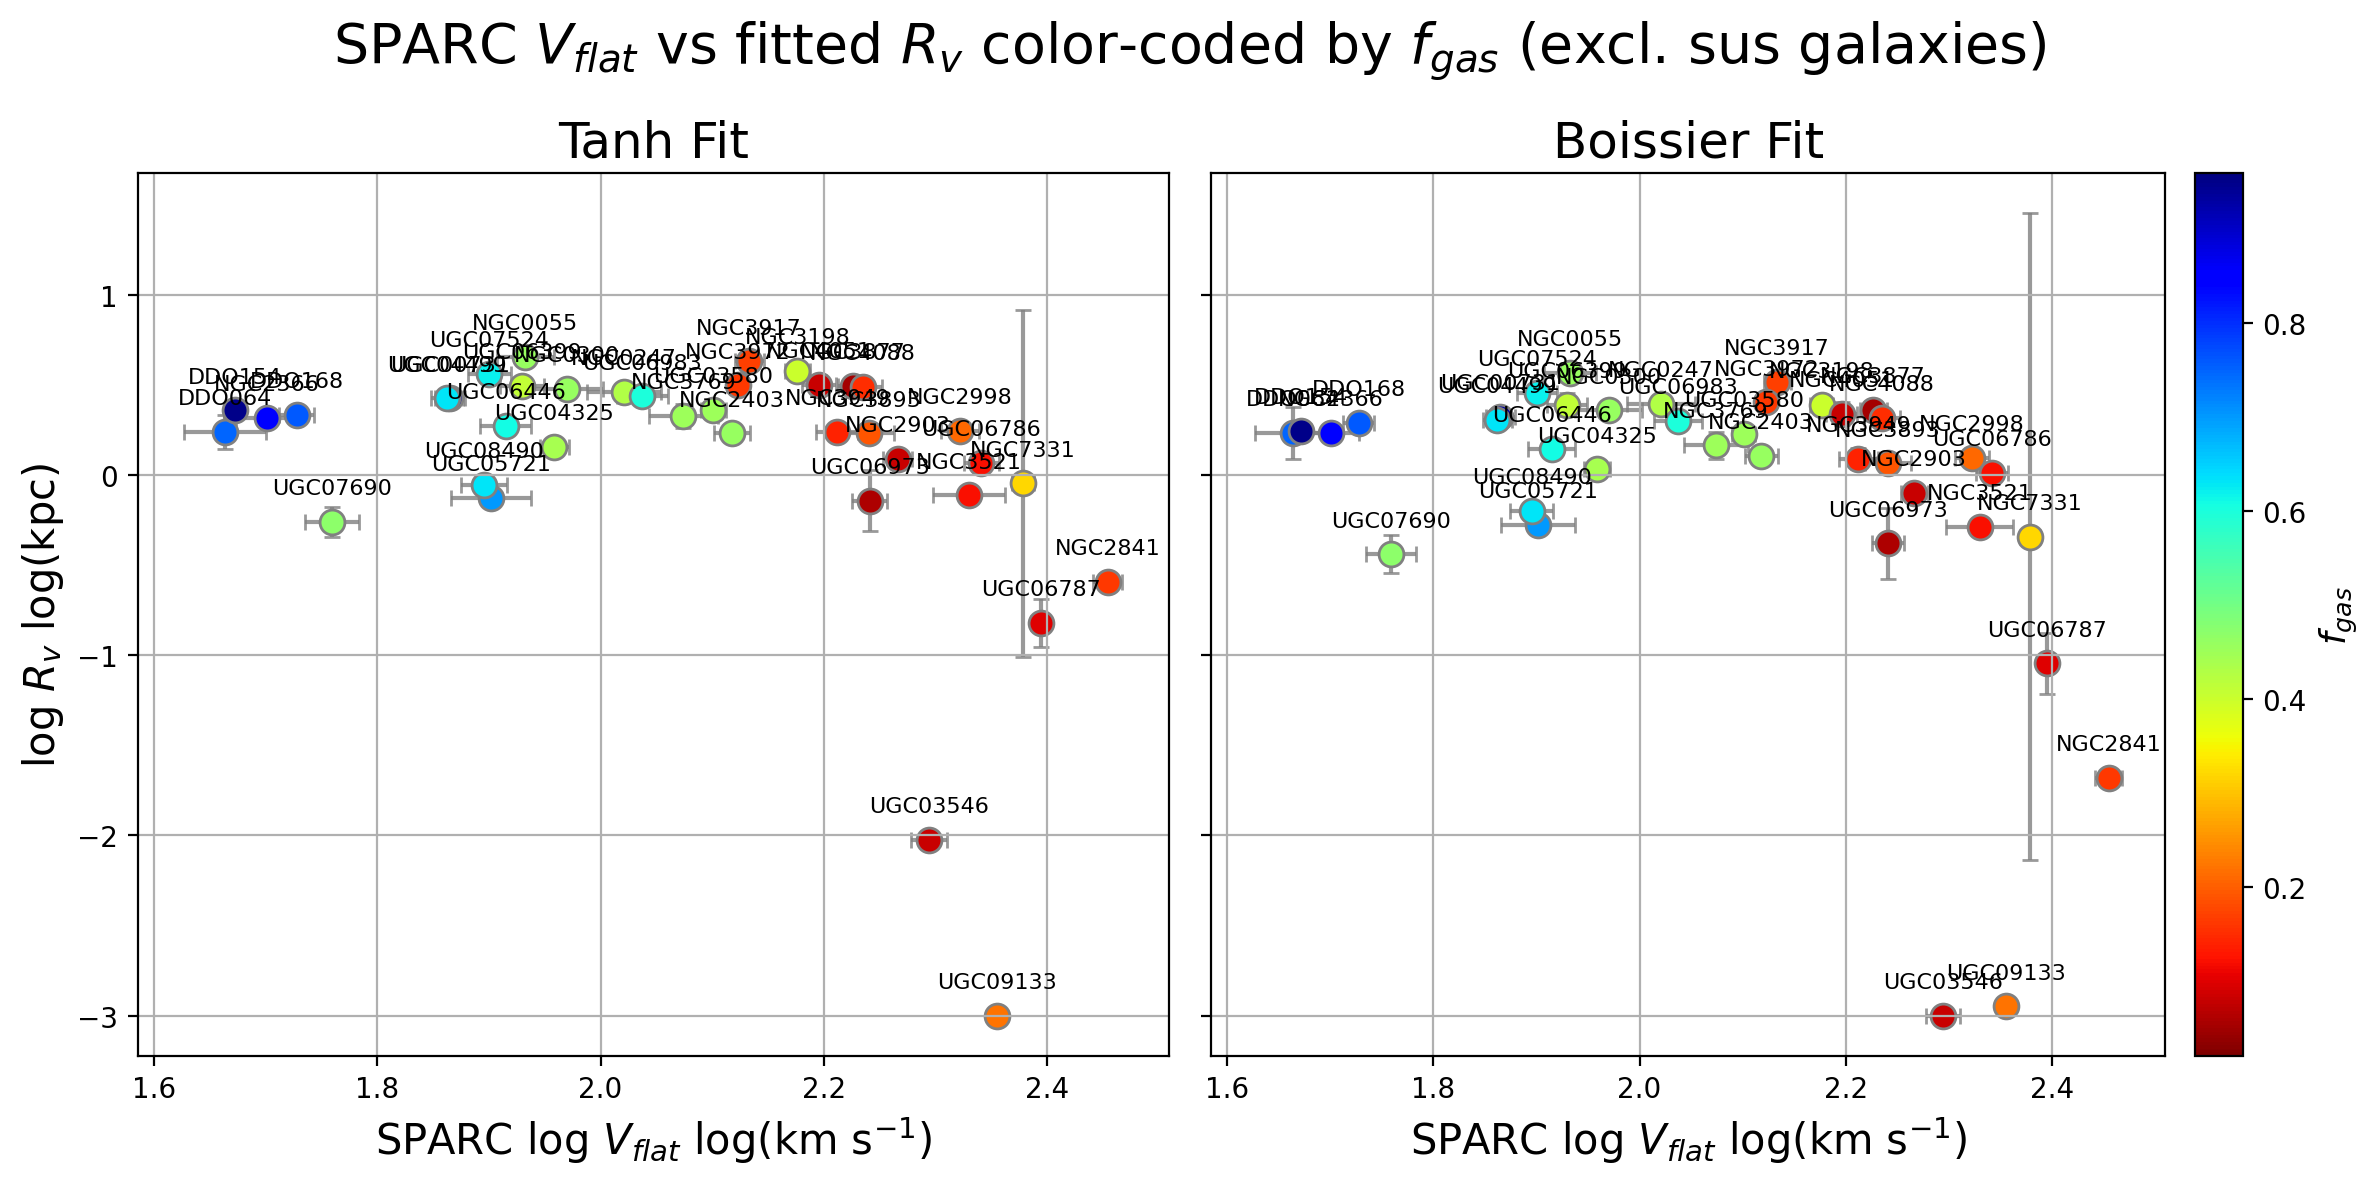

⏱ 0.7120s


In [20]:
# plot again log r_v vs SPARC log v_flat but color-coded by f_gas, excluding sus galaxies

norm = mpl.colors.Normalize(vmin=np.nanmin(f_gas.values), vmax=np.nanmax(f_gas.values))
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')

# TANH
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    fgas = bary_idx.at[galaxy, 'fgas']
    if finite_pos(rvt, vflat, fgas):
        color = cmap(norm(fgas))
        ax.scatter(np.log10(vflat), np.log10(rvt), s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(np.log10(vflat), np.log10(rvt), xerr=vflat_err/vflat/np.log(10), yerr=rvt_err/rvt/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (np.log10(vflat), np.log10(rvt)), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
ax.set_ylabel(r"log $R_v$ log(kpc)", fontsize=15)
ax.set_xlabel(r"SPARC log $V_{flat}$ log(km s$^{-1}$)", fontsize=15)
ax.set_title("Tanh Fit", fontsize=18)
ax.grid()

# BOISSIER
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    fgas = bary_idx.at[galaxy, 'fgas']
    if finite_pos(rvb, vflat, fgas):
        color = cmap(norm(fgas))
        ax.scatter(np.log10(vflat), np.log10(rvb), s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(np.log10(vflat), np.log10(rvb), xerr=vflat_err/vflat/np.log(10), yerr=rvb_err/rvb/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (np.log10(vflat), np.log10(rvb)), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
    
ax.set_xlabel(r"SPARC log $V_{flat}$ log(km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC $V_{flat}$ vs fitted $R_{v}$ color-coded by $f_{gas}$ (excl. sus galaxies)", fontsize=20)

divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(r"$f_{gas}$", fontsize=13)

plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/fgas_vs_Rv_excl_sus.png')
plt.show()

/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3954133138.py:12: RuntimeWarning: divide by zero encountered in log10
  if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3954133138.py:31: RuntimeWarning: divide by zero encountered in log10
  if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3954133138.py:50: RuntimeWarning: divide by zero encountered in log10
  if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3954133138.py:69: RuntimeWarning: divide by zero encountered in log10
  if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):


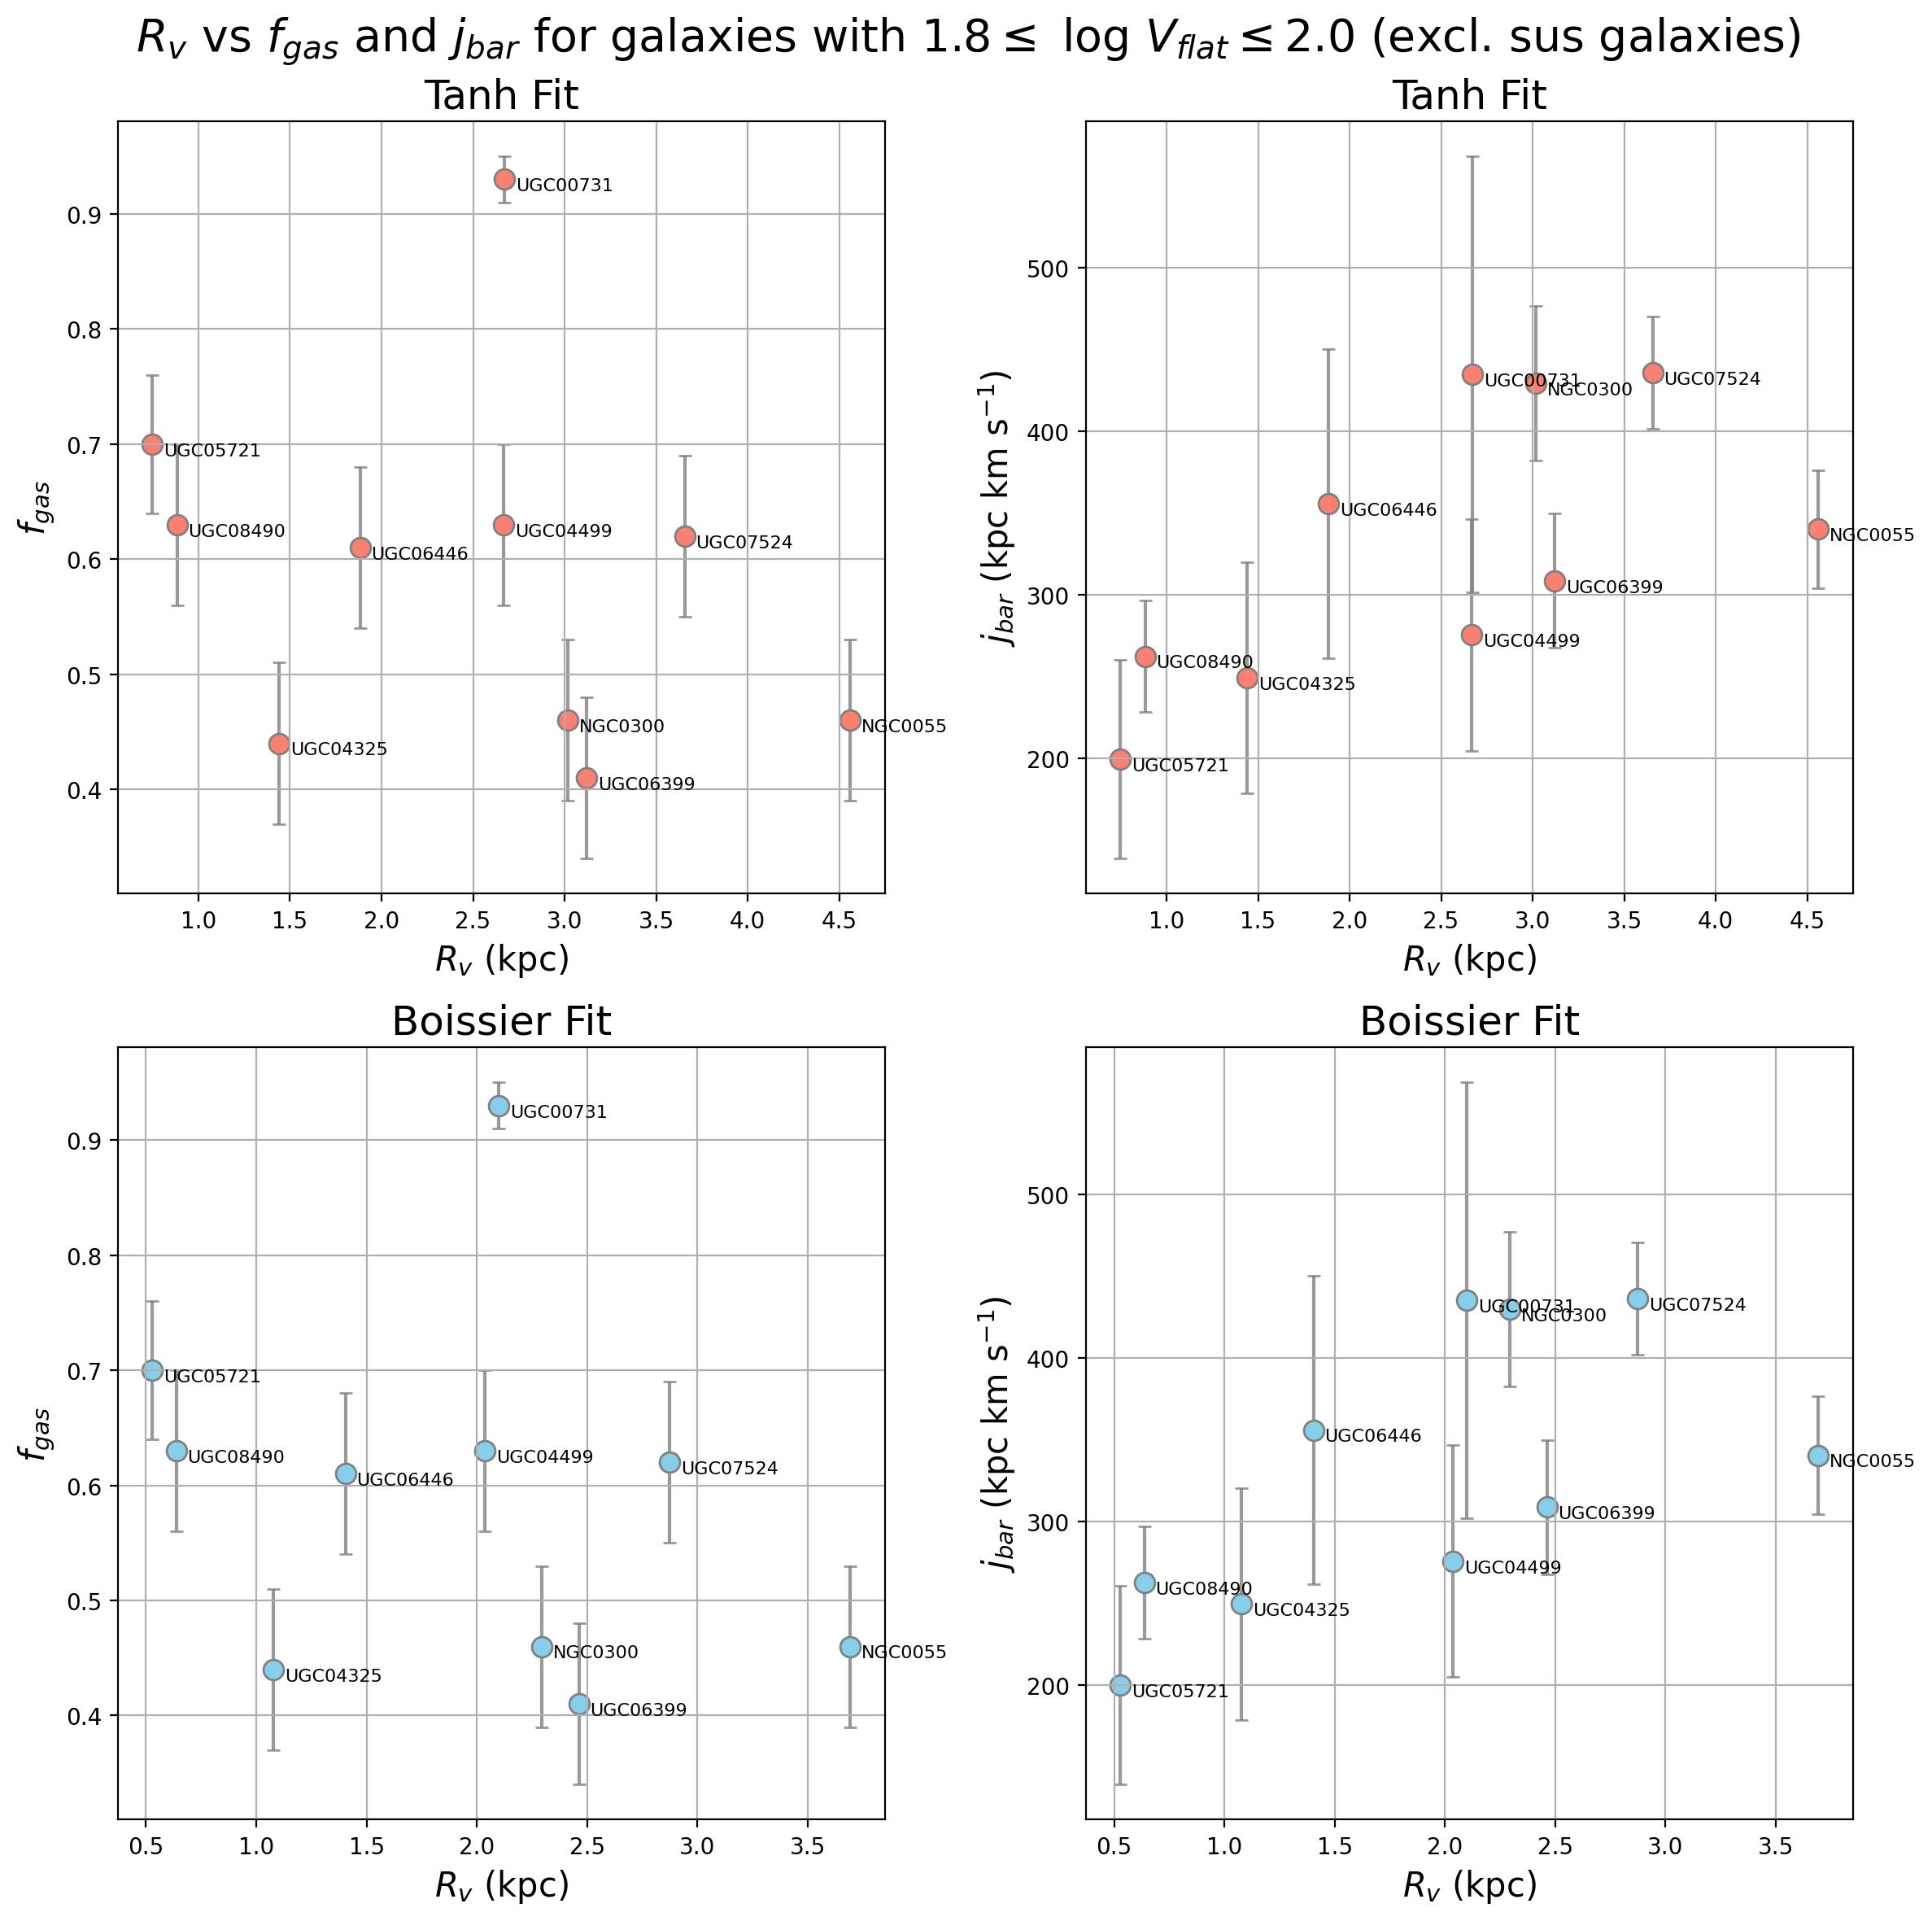

⏱ 0.5333s


In [21]:
# plot f_gas vs R_v and j_bar vs R_v for both fit types, excluding sus galaxies, in a 2x2 grid, for galaxies with log v_flat in the range 1.8 - 2.0
# add annotation with name of each galaxy next to its point

fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=200, facecolor='w')

# TANH f_gas vs R_v
ax = axes[0,0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
        continue
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    fgas = bary_idx.at[galaxy, 'fgas']
    e_fgas = bary_idx.at[galaxy, 'e_fgas']
    if finite_pos(rvt, fgas):
        ax.scatter(rvt, fgas, s=80, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(rvt, fgas, yerr=e_fgas, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (rvt, fgas), textcoords="offset points", xytext=(5,-5), ha='left', fontsize=8)
ax.set_ylabel(r"$f_{gas}$", fontsize=15)
ax.set_xlabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_title("Tanh Fit", fontsize=18)
ax.grid()
# TANH j_bar vs R_v
ax = axes[0,1]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
        continue
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    e_jbar = bary_idx.at[galaxy, 'e_j']
    if finite_pos(rvt, jbar):
        ax.scatter(rvt, jbar, s=80, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(rvt, jbar, yerr=e_jbar, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (rvt, jbar), textcoords="offset points", xytext=(5,-5), ha='left', fontsize=8)
ax.set_ylabel(r"$j_{bar}$ (kpc km s$^{-1}$)", fontsize=15)
ax.set_xlabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_title("Tanh Fit", fontsize=18)
ax.grid()
# BOISSIER f_gas vs R_v
ax = axes[1,0]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
        continue
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    fgas = bary_idx.at[galaxy, 'fgas']
    e_fgas = bary_idx.at[galaxy, 'e_fgas']
    if finite_pos(rvb, fgas):
        ax.scatter(rvb, fgas, s=80, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(rvb, fgas, yerr=e_fgas, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (rvb, fgas), textcoords="offset points", xytext=(5,-5), ha='left', fontsize=8)
ax.set_xlabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_ylabel(r"$f_{gas}$", fontsize=15)
ax.set_title("Boissier Fit", fontsize=18)
ax.grid()
# BOISSIER j_bar vs R_v
ax = axes[1,1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    if not (np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0)):
        continue
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    e_jbar = bary_idx.at[galaxy, 'e_j']
    if finite_pos(rvb, jbar):
        ax.scatter(rvb, jbar, s=80, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(rvb, jbar, yerr=e_jbar, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        ax.annotate(galaxy, (rvb, jbar), textcoords="offset points", xytext=(5,-5), ha='left', fontsize=8)
ax.set_xlabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_ylabel(r"$j_{bar}$ (kpc km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit", fontsize=18)
ax.grid()
plt.suptitle(r"$R_{v}$ vs $f_{gas}$ and $j_{bar}$ for galaxies with $1.8 \leq$ log $V_{flat} \leq 2.0$ (excl. sus galaxies)", fontsize=20)
plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/Rv_vs_fgas_jbar_excl_sus_logvflat_1.8-2.0.png')
plt.show()

In [22]:
# print names of galaxies in the range 1.8 - 2.0 log v_flat, save to array
galaxies_in_range = []
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    if np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0):
        galaxies_in_range.append(galaxy)

⏱ 0.0009s


/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/1182348307.py:7: RuntimeWarning: divide by zero encountered in log10
  if np.isfinite(vflat) and (1.8 <= np.log10(vflat) <= 2.0):


In [23]:
print(galaxies_in_range)
print(len(galaxies_in_range))

['NGC0055', 'NGC0300', 'UGC00731', 'UGC04325', 'UGC04499', 'UGC05721', 'UGC06399', 'UGC06446', 'UGC07524', 'UGC08490']
10
⏱ 0.0002s


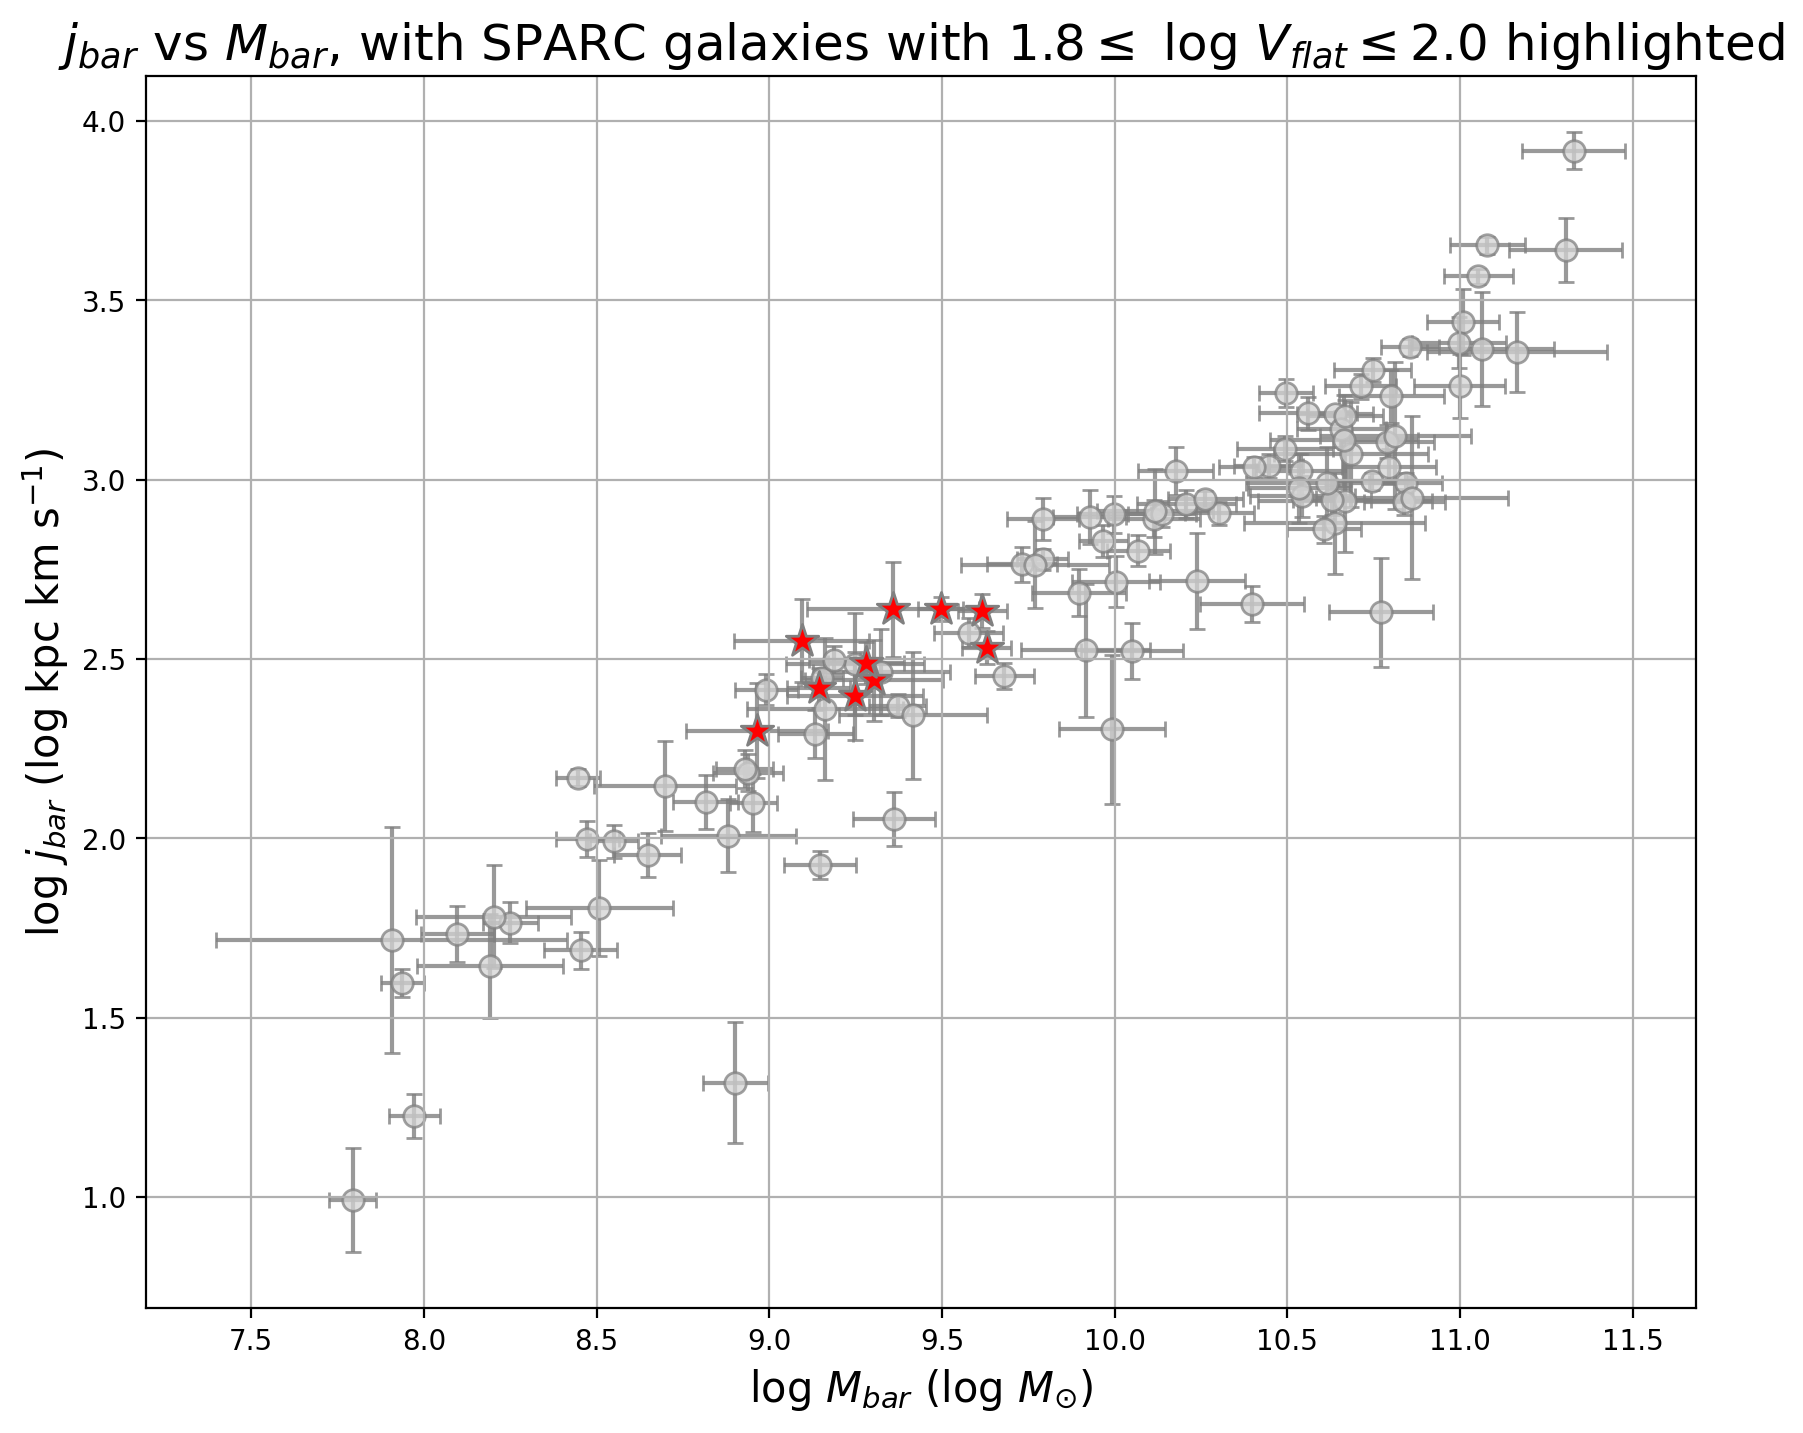

⏱ 0.6306s


In [24]:
# make pavel plot (j_bar vs M_bar) with all galaxies in baryons1.csv, but the 10 galaxies in the range 1.8 - 2.0 log v_flat with a different color

fig = plt.figure(figsize=(10, 8), dpi=200)

for galaxy in bary['Name']:
    if galaxy not in bary_idx.index:
        continue
    mbar = bary_idx.at[galaxy, 'Mass(Msun)']
    jbar = bary_idx.at[galaxy, 'j']
    e_mbar = bary_idx.at[galaxy, 'e_Mass(Msun)']
    e_jbar = bary_idx.at[galaxy, 'e_j']
    if finite_pos(mbar, jbar):
        if galaxy in galaxies_in_range:
            plt.scatter(np.log10(mbar), np.log10(jbar), s=150, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            #plt.annotate(galaxy, (np.log10(mbar), np.log10(jbar)), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            plt.scatter(np.log10(mbar), np.log10(jbar), s=60, alpha=.75, label=galaxy, c='lightgrey', edgecolors='grey')
        plt.errorbar(np.log10(mbar), np.log10(jbar), xerr=e_mbar/mbar/np.log(10), yerr=e_jbar/jbar/np.log(10), fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
        
plt.xlabel(r"log $M_{bar}$ (log $M_{\odot}$)", fontsize=15)
plt.ylabel(r"log $j_{bar}$ (log kpc km s$^{-1}$)", fontsize=15)
plt.title(r"$j_{bar}$ vs $M_{bar}$, with SPARC galaxies with $1.8 \leq$ log $V_{flat} \leq 2.0$ highlighted", fontsize=18)
plt.grid()
#plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/pavel_plot_highlight_logvflat_1.8-2.0.png')
plt.show()

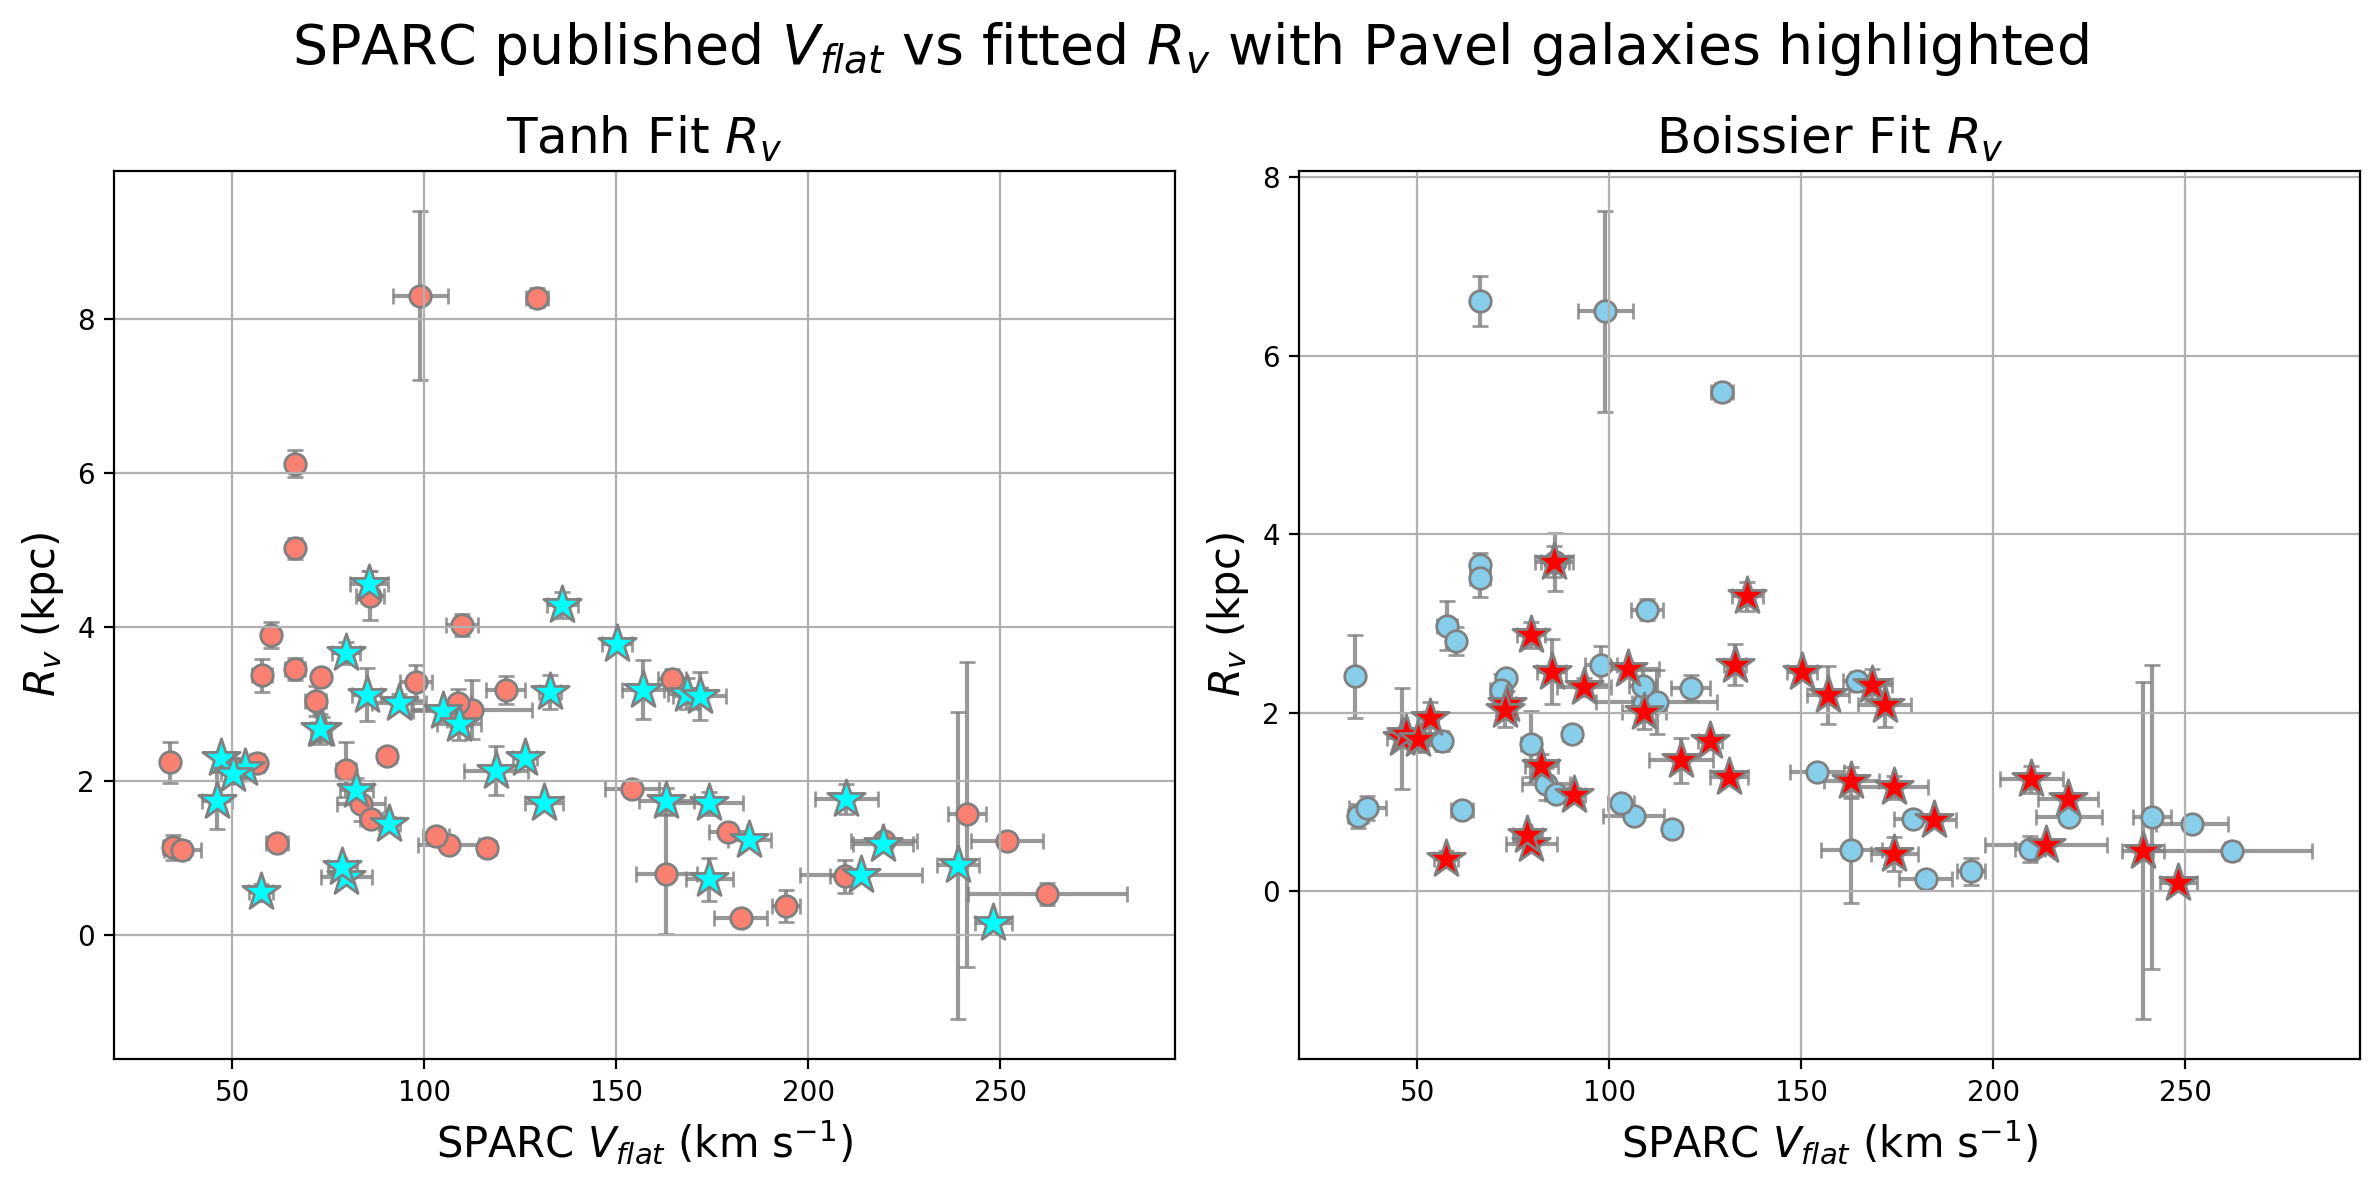

⏱ 0.8337s


In [25]:
# plot Rv vs vflat for all SPARC galaxies, excluding sus ones, and highlight the galaxies in the Pavel set. do two plots, one for tanh and one for boissier
#annotate galaxies in the Pavel dataset

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, facecolor='w')
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vflat) and np.isfinite(rvt_err) and np.isfinite(vflat_err) and rvt>0 and vflat>0 and rvt_err>0 and vflat_err>0:
        if galaxy in bary_idx.index:
            ax.scatter(vflat, rvt, s=200, label=galaxy, c='cyan', edgecolors='grey', marker='*', zorder=5)
            #ax.annotate(galaxy, (vflat, rvt), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvt, s=60, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, rvt, xerr=vflat_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Tanh Fit $R_v$", fontsize=18)
ax.grid()

ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in sparc_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vflat) and np.isfinite(rvb_err) and np.isfinite(vflat_err) and rvb>0 and vflat>0 and rvb_err>0 and vflat_err>0:
        if galaxy in bary_idx.index:
            ax.scatter(vflat, rvb, s=200, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            #ax.annotate(galaxy, (vflat, rvb), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvb, s=60, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, rvb, xerr=vflat_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_title(r"Boissier Fit $R_v$", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC published $V_{flat}$ vs fitted $R_{v}$ with Pavel galaxies highlighted", fontsize=20)
plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/SPARC_Rv_vs_Vflat_using_SPARC_vflat_highlight_pavel.png')
plt.show()

In [26]:
# find galaxy with sparc vflat > 150 and Rv from tanh > 4 kpc
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    _, _, _, rvt, _ = tanh_map[galaxy]
    _, _, _, rvb, _ = bois_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vflat) and vflat > 150 and rvt > 4:
        print(f"Galaxy {galaxy} has Vflat = {vflat} km/s and Rv_tanh = {rvt} kpc and Rv_boissier = {rvb} kpc")

⏱ 0.0013s


In [27]:
# out of the galaxies in both SPARC and Pavel set, print name and vflat value of galaxies with SPARC vflat < 1.8 as well as those with log Rv (from tanh) < 0.0
# print the names and vflat values!

for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index or galaxy in sus_all_fit or galaxy not in bary_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    _, _, _, rvt, _ = tanh_map[galaxy]
    if np.isfinite(vflat) and np.isfinite(rvt):
        if np.log10(vflat) < 1.8 or np.log10(rvt) < 0.0:
            print(f"Galaxy {galaxy} has Vflat = {vflat} km/s and Rv_tanh = {rvt} kpc")

Galaxy DDO064 has Vflat = 46.1 km/s and Rv_tanh = 1.740459437437763 kpc
Galaxy DDO154 has Vflat = 47.0 km/s and Rv_tanh = 2.28989822701971 kpc
Galaxy DDO168 has Vflat = 53.4 km/s and Rv_tanh = 2.1716945507317833 kpc
Galaxy NGC2366 has Vflat = 50.2 km/s and Rv_tanh = 2.0820102042417226 kpc
Galaxy NGC2841 has Vflat = 284.8 km/s and Rv_tanh = 0.25663269525844856 kpc
Galaxy NGC3521 has Vflat = 213.7 km/s and Rv_tanh = 0.7723217452332337 kpc
Galaxy NGC4389 has Vflat = 0.0 km/s and Rv_tanh = 4.167989120752931 kpc
Galaxy NGC7331 has Vflat = 239.0 km/s and Rv_tanh = 0.9001105301835473 kpc
Galaxy NGC7793 has Vflat = 0.0 km/s and Rv_tanh = 1.0727217806911713 kpc
Galaxy UGC03546 has Vflat = 196.9 km/s and Rv_tanh = 0.009475838871872477 kpc
Galaxy UGC05721 has Vflat = 79.7 km/s and Rv_tanh = 0.7488332611207592 kpc
Galaxy UGC06787 has Vflat = 248.1 km/s and Rv_tanh = 0.15088659009407435 kpc
Galaxy UGC06973 has Vflat = 174.2 km/s and Rv_tanh = 0.7202364163970632 kpc
Galaxy UGC07323 has Vflat = 0.0 k

/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/1556886919.py:10: RuntimeWarning: divide by zero encountered in log10
  if np.log10(vflat) < 1.8 or np.log10(rvt) < 0.0:


/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3104952779.py:23: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(0,1,100), 10**(2.466+0.46*np.log10(np.linspace(0,1,100))), ls='--', c='black', label=r'Pavel fit with $M_{\rm bar} = 10^{9.2}$')
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3104952779.py:24: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(0,1,100), 10**(2.247+0.46*np.log10(np.linspace(0,1,100))), ls=':', c='black', label=r'Pavel fit with $M_{\rm bar} = 10^{8.9} - 10^{9.5}$')
/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_79559/3104952779.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(0,1,100), 10**(2.685+0.46*np.log10(np.linspace(0,1,100))), ls=':', c='black')


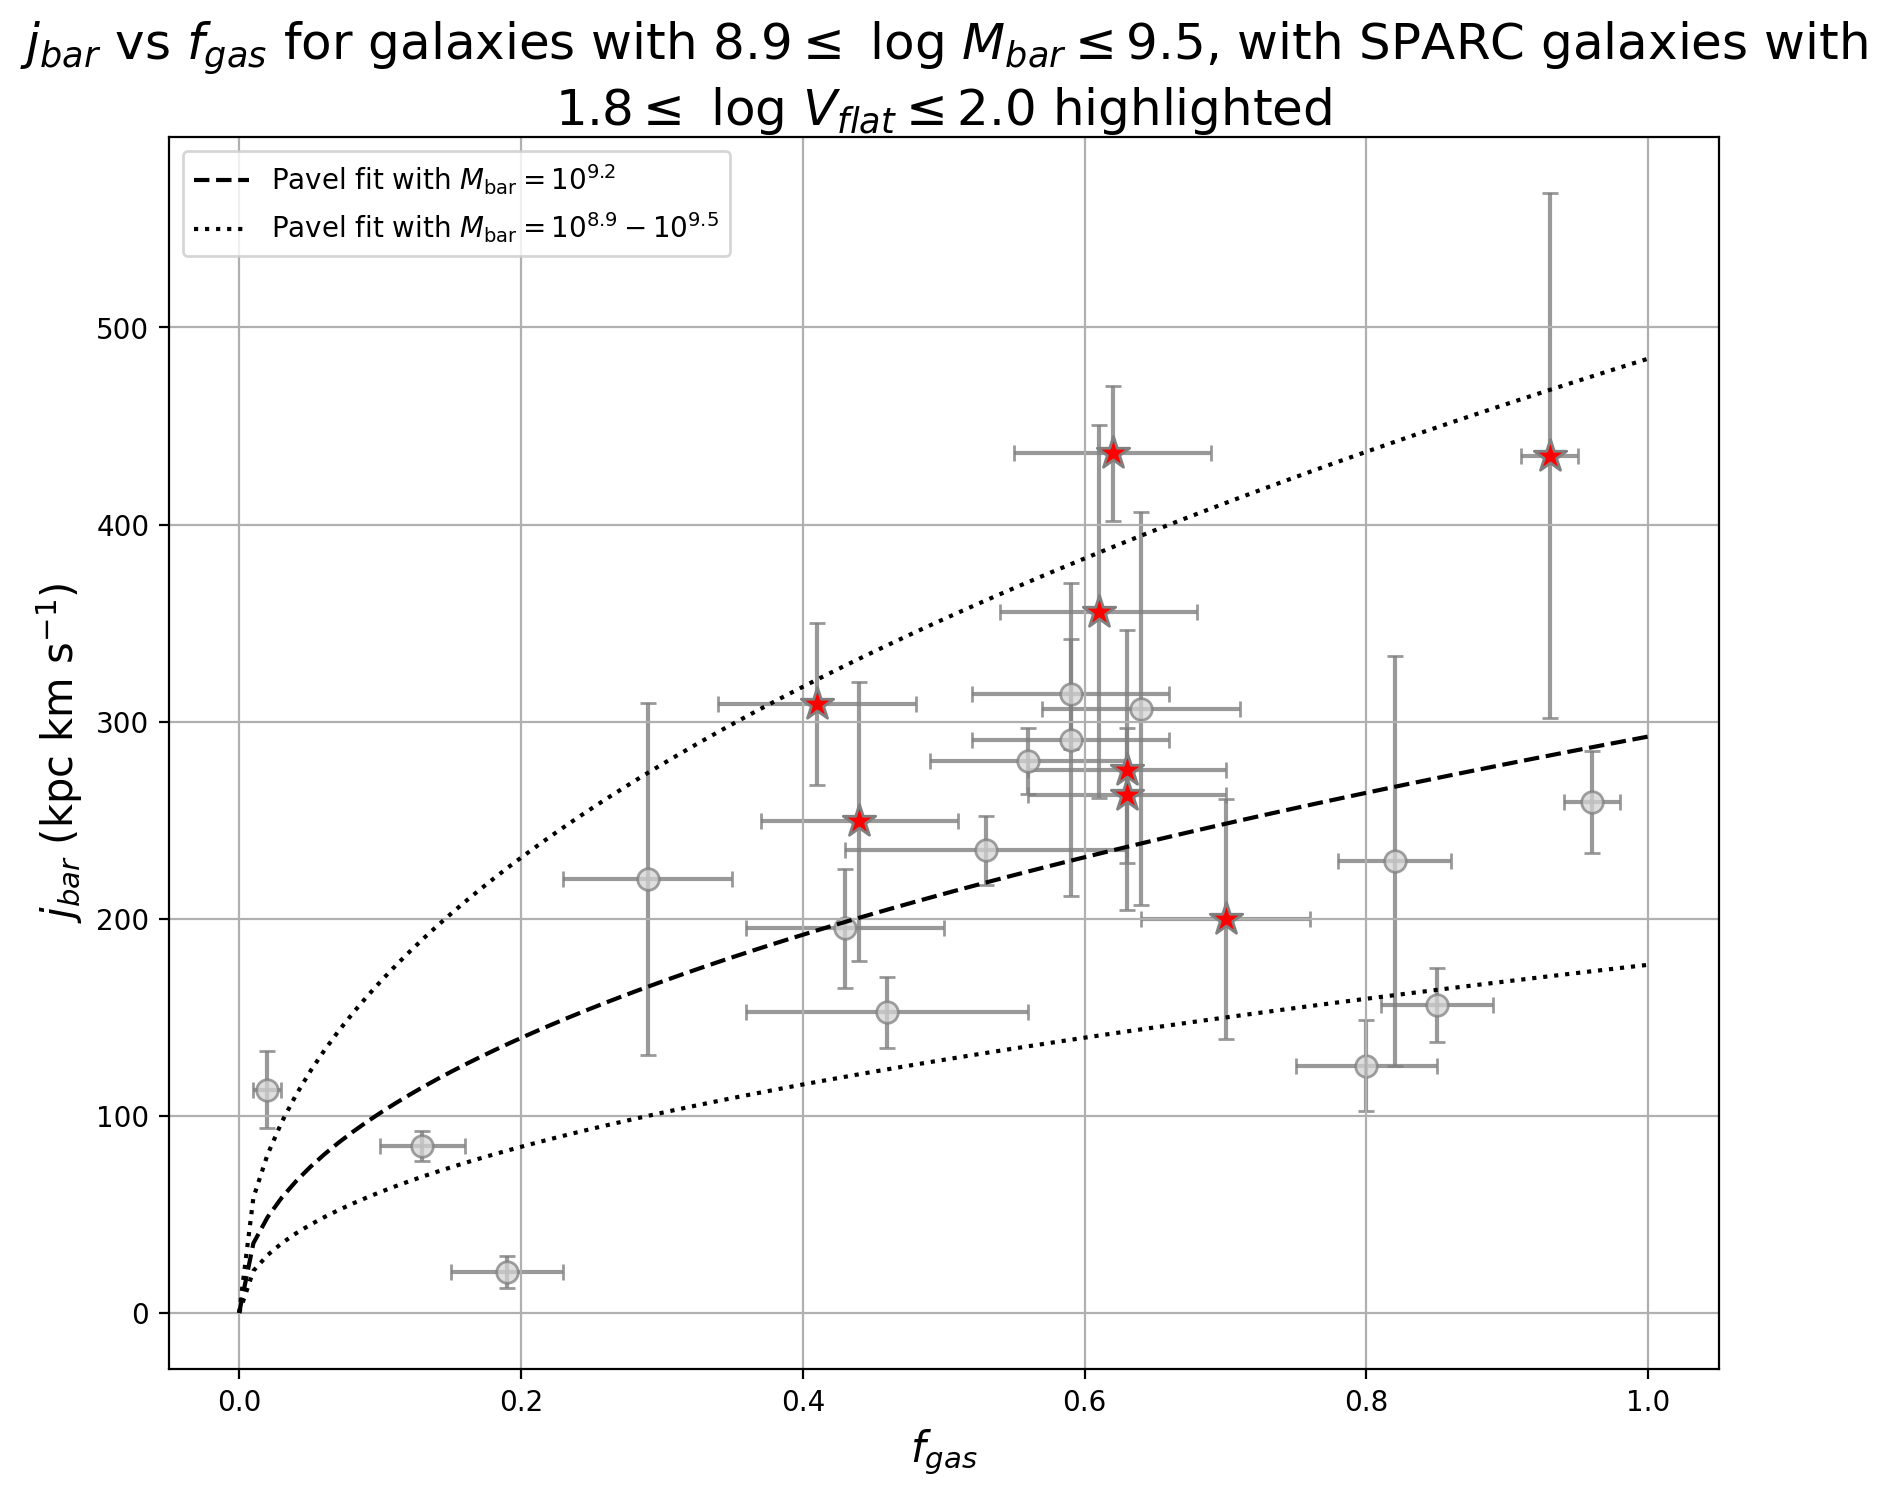

⏱ 0.3307s


In [28]:
# for galaxies in the range log Mbar 9 - 9.5 from the Pavel set, plot f_gas vs j_bar, but 10 galaxies in the range 1.8 - 2.0 log v_flat with a different color

from textwrap import wrap


fig = plt.figure(figsize=(10, 8), dpi=200, facecolor='w')
for galaxy in bary['Name']:
    if galaxy not in bary_idx.index:
        continue
    mbar = bary_idx.at[galaxy, 'Mass(Msun)']
    jbar = bary_idx.at[galaxy, 'j']
    e_jbar = bary_idx.at[galaxy, 'e_j']
    fgas = bary_idx.at[galaxy, 'fgas']
    e_fgas = bary_idx.at[galaxy, 'e_fgas']
    if finite_pos(mbar, jbar, fgas) and (8.9 <= np.log10(mbar) <= 9.5):
        if galaxy in galaxies_in_range:
            plt.scatter(fgas, jbar, s=150, c='red', edgecolors='grey', marker='*', zorder=5)
            #plt.annotate(galaxy, (fgas, jbar), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            plt.scatter(fgas, jbar, s=60, alpha=.75, c='lightgrey', edgecolors='grey')
        plt.errorbar(fgas, jbar, yerr=e_jbar, xerr=e_fgas, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)

plt.plot(np.linspace(0,1,100), 10**(2.466+0.46*np.log10(np.linspace(0,1,100))), ls='--', c='black', label=r'Pavel fit with $M_{\rm bar} = 10^{9.2}$')
plt.plot(np.linspace(0,1,100), 10**(2.247+0.46*np.log10(np.linspace(0,1,100))), ls=':', c='black', label=r'Pavel fit with $M_{\rm bar} = 10^{8.9} - 10^{9.5}$')
plt.plot(np.linspace(0,1,100), 10**(2.685+0.46*np.log10(np.linspace(0,1,100))), ls=':', c='black')
  
plt.xlabel(r"$f_{gas}$", fontsize=15)
plt.ylabel(r"$j_{bar}$ (kpc km s$^{-1}$)", fontsize=15)
plt.title(r"$j_{bar}$ vs $f_{gas}$ for galaxies with $8.9 \leq$ log $M_{bar} \leq 9.5$, with SPARC galaxies with $1.8 \leq$ log $V_{flat} \leq 2.0$ highlighted", fontsize=18, wrap=True)
plt.grid()
plt.legend()
#plt.tight_layout()
plt.savefig(outdir+'rotcurves/plots/jbar_vs_fgas_highlight_logvflat_1.8-2.0_logmbar_9-9.5.png')
plt.show()

In [29]:
i = 0
for galaxy in gab_names_finc:
    if galaxy not in bary_idx.index or galaxy in sus_all_fit or galaxy not in sparc_idx.index:
        continue
    i += 1
    
print(i)

41
⏱ 0.0004s
